# Sistema Predictivo de Apoyo a la Toma de Decisiones Editoriales
### Predicción del Riesgo de Bajo Desempeño de Noticias mediante Ciencia de Datos




## 1. Configuración y carga de datos

Cargamos los dos archivos fuente:
- `cms-2025.csv`: artículos del CMS (título, categoría, autor, contenido, multimedia, visitas).
- `google-analytics-2025.csv`: export de GA4 a nivel página individual.



In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # shap y sentence-transformers no vienen preinstalados en Colab (a diferencia de
     # sklearn/xgboost/seaborn, que sí) se instalan aquí para que el notebook corra en un entorno limpio.
    import subprocess
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', 'shap', 'sentence-transformers'],
        check=True,
    )

    from google.colab import drive
    drive.mount('/content/drive')
    # Ajustar esta ruta cuando se suba la carpeta `datos/` dentro de tu Drive
    DATA_DIR = Path('/content/drive/MyDrive/proyecto_final/datos')
else:
    DATA_DIR = Path('datos')

CMS_PATH = DATA_DIR / 'cms-2025.csv'
GA_PATH = DATA_DIR / 'google-analytics-2025.csv'

In [2]:
cms = pd.read_csv(CMS_PATH, encoding='latin-1')

print(f'Filas: {cms.shape[0]:,} | Columnas: {cms.shape[1]}')
cms.head(3)

Filas: 34,734 | Columnas: 18


,id,titulo,caracteres_titulo,categoria,visitasClean,nombre,fecha,visitasFechaUltima,nota,URL,h1,h2,link_build,imagen,video,twitter,facebook,Audio
0,1355202,Con baile y pirotecnia despiden al 2024 en el ...,66,Veracruz,52,José Antonio Cabrera,1/1/2025 0:14,22/7/2026 10:52:35,"<p style=""text-align: justify;"">En un ambiente...",veracruz/1355202/con-baile-y-pirotecnia-despid...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1355203,Con desfile y pirotecnia reciben el Año Nuevo ...,77,Boca del Río,56,José Antonio Cabrera,1/1/2025 2:01,21/7/2026 19:42:44,"<p style=""text-align: justify;"">Con un desfile...",boca-del-rio/1355203/con-desfile-y-pirotecnia-...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1355204,Desfiles para despedir El Viejo serán cada año...,86,Boca del Río,17,José Antonio Cabrera,1/1/2025 2:11,24/7/2026 16:48:52,"<p style=""text-align: justify;"">La secretaria ...",boca-del-rio/1355204/desfiles-para-despedir-el...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [3]:
print('=== DATOS CMS ===')
print(f'Shape: {cms.shape}')

print('\n--- Tipos de dato ---')
print(cms.dtypes)

print('\n--- Nulos por columna ---')
print(cms.isna().sum())


display(cms.describe())


display(cms.describe(include='object'))

=== DATOS CMS ===
Shape: (34734, 18)

--- Tipos de dato ---
id                      int64
titulo                 object
caracteres_titulo       int64
categoria              object
visitasClean            int64
nombre                 object
fecha                  object
visitasFechaUltima     object
nota                   object
URL                    object
h1                    float64
h2                    float64
link_build            float64
imagen                float64
video                 float64
twitter               float64
facebook              float64
Audio                 float64
dtype: object

--- Nulos por columna ---
id                    0
titulo                0
caracteres_titulo     0
categoria             0
visitasClean          0
nombre                0
fecha                 0
visitasFechaUltima    0
nota                  0
URL                   2
h1                    2
h2                    2
link_build            2
imagen                2
video                 2

,id,caracteres_titulo,visitasClean,h1,h2,link_build,imagen,video,twitter,facebook,Audio
count,3.473400e+04,34734.000000,34734.000000,34732.000000,34732.000000,34732.000000,34732.000000,34732.000000,34732.000000,34732.000000,34732.00000
mean,1.378306e+06,74.187943,642.366932,0.000374,0.042785,0.635927,0.084763,0.011085,0.148307,0.112260,0.22665
std,1.341510e+04,14.534195,2779.749126,0.042589,0.440409,1.779350,0.489399,0.120790,0.448142,0.379626,0.41867
min,1.355202e+06,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,1.366653e+06,65.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,1.378346e+06,75.000000,57.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,1.389952e+06,85.000000,570.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,1.401487e+06,173.000000,250855.000000,6.000000,13.000000,74.000000,26.000000,6.000000,20.000000,13.000000,1.00000


,titulo,categoria,nombre,fecha,visitasFechaUltima,nota,URL
count,34734,34734,34734,34734,34734,34734,34732
unique,33829,11,14,34257,31428,34504,34732
top,"Tome precauciones, hay cierre parcial de circu...",Nacional,Javier Duque,9/8/2025 9:07,22/6/2026 02:25:05,"<p style=""text-align: justify;"">Hay que tener ...",veracruz/1355202/con-baile-y-pirotecnia-despid...
freq,17,6200,7723,3,19,5,1


In [4]:
# Se coloca encoding='latin-1'. Verificado directamente sobre el archivo.
ga_raw = pd.read_csv(GA_PATH, encoding='latin-1')

print(f'Filas: {ga_raw.shape[0]:,} | Columnas: {ga_raw.shape[1]}')
ga_raw.head(3)

Filas: 100,000 | Columnas: 11


,Page title and screen class,Page path and screen class,Views,Active users,Views per active user,Average engagement time per active user,Event count,Key events,Total revenue,Engagement rate,Bounce rate
0,Noticias de Veracruz | xeu noticias,/,4078486,297328,13.717127,531.940594,63204490,2320014,88602.484290,0.863814,0.136186
1,MainActivity,MainActivity,1568978,6256,250.795716,5976.810102,3756585,318,5507.533242,0.921281,0.078719
2,NotaCompleta,NotaCompleta,1243399,4737,262.486595,11844.913030,2836861,125,3516.372166,0.971385,0.028615


In [5]:
print('=== Datos GA4 ===')
print(f'Shape: {ga_raw.shape}')

print('\n--- Tipos de dato,-')
print(ga_raw.dtypes)

print('\n--- Nulos por columna ---')
print(ga_raw.isna().sum())

display(ga_raw.describe())

display(ga_raw.describe(include='object'))

=== Datos GA4 ===
Shape: (100000, 11)

--- Tipos de dato,-
Page title and screen class                 object
Page path and screen class                  object
Views                                        int64
Active users                                 int64
Views per active user                      float64
Average engagement time per active user    float64
Event count                                  int64
Key events                                   int64
Total revenue                              float64
Engagement rate                            float64
Bounce rate                                float64
dtype: object

--- Nulos por columna ---
Page title and screen class                0
Page path and screen class                 1
Views                                      0
Active users                               0
Views per active user                      0
Average engagement time per active user    0
Event count                                0
Key events              

,Views,Active users,Views per active user,Average engagement time per active user,Event count,Key events,Total revenue,Engagement rate,Bounce rate
count,1.000000e+05,100000.000000,100000.000000,100000.000000,1.000000e+05,1.000000e+05,100000.000000,100000.000000,100000.000000
mean,4.535759e+02,233.500990,1.261143,22.670895,4.393428e+03,2.715083e+02,5.502255,0.563228,0.436702
std,1.574764e+04,1706.269991,2.500976,80.627467,2.073869e+05,7.817607e+03,301.922682,0.349800,0.349787
min,1.000000e+00,0.000000,0.000000,0.000000,1.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,1.000000e+00,1.000000,1.000000,2.000000,1.200000e+01,1.000000e+00,0.000568,0.333333,0.154930
50%,6.000000e+00,5.000000,1.078431,15.658288,5.500000e+01,4.000000e+00,0.044699,0.636364,0.363636
75%,8.500000e+01,70.000000,1.297297,31.358165,7.912500e+02,2.800000e+01,0.675381,0.844828,0.666667
max,4.078486e+06,297328.000000,390.000000,12579.982460,6.320449e+07,2.320014e+06,88602.484290,1.000000,1.000000


,Page title and screen class,Page path and screen class
count,100000,99999
unique,89428,95303
top,Astroguía | Opinión | xeu noticias Veracruz,/nota.cfm
freq,158,907


## 2. Limpieza de fechas y preparación de GA4 para el cruce

Dos cosas que hay que resolver antes de unir los datasets:

 1. **`fecha` en el CMS mezcla formatos** (`23/1/2025 16:44:02` y `1/1/2025 0:14`), usamos `format='mixed'` para que pandas detecte cada formato fila por filay no dejar filas sin parsear.
2. **El export de GA4 trae rutas duplicadas.** Cada `Page path and screen class` puede aparecer varias veces porque GA4 desglosa por `Page title`, y el mismo artículo tiene títulos distintos según el idioma del navegador/Google Translate. Vamos a agregar por ruta, sumamos las métricas (Views, usuarios, eventos, revenue) y promediamos las tasas (engagement/bounce) ponderadas por Views, para no perder información real de tráfico.

In [6]:
cms['fecha'] = pd.to_datetime(cms['fecha'], format='mixed', dayfirst=True)
cms['visitasFechaUltima'] = pd.to_datetime(cms['visitasFechaUltima'], format='mixed', dayfirst=True)

print('Fechas sin parsear (fecha):', cms['fecha'].isna().sum())
print('Rango:', cms['fecha'].min(), '→', cms['fecha'].max())

Fechas sin parsear (fecha): 0
Rango: 2025-01-01 00:14:00 → 2025-12-31 11:39:35


In [7]:
# Nos quedamos solo con páginas web (empiezan con '/'); descartamos pantallas de la app móvil
# (MainActivity, NotaCompleta, SplashScreen) y la fila sin ruta (NaN)
path_col = 'Page path and screen class'
ga_web = ga_raw.dropna(subset=[path_col]).copy()
ga_web = ga_web[ga_web[path_col].str.startswith('/')]

print(f'{len(ga_web):,} de {len(ga_raw):,} filas son páginas web')
print(f'Rutas únicas: {ga_web[path_col].nunique():,} | Filas duplicadas por ruta: {ga_web[path_col].duplicated().sum():,}')

def promedio_ponderado(grupo, columna, peso='Views'):
    if grupo[peso].sum() == 0:
        return grupo[columna].mean()
    return np.average(grupo[columna], weights=grupo[peso])

ga_agg = (
    ga_web.groupby(path_col)
    .apply(lambda g: pd.Series({
        'ga_views': g['Views'].sum(),
        'ga_active_users': g['Active users'].sum(),
        'ga_event_count': g['Event count'].sum(),
        'ga_key_events': g['Key events'].sum(),
        'ga_revenue': g['Total revenue'].sum(),
        'ga_engagement_rate': promedio_ponderado(g, 'Engagement rate'),
        'ga_bounce_rate': promedio_ponderado(g, 'Bounce rate'),
    }), include_groups=False)
    .reset_index()
)

print(f'Rutas agregadas: {len(ga_agg):,}')
ga_agg.head(3)

99,940 de 100,000 filas son páginas web
Rutas únicas: 95,244 | Filas duplicadas por ruta: 4,696
Rutas agregadas: 95,244


,Page path and screen class,ga_views,ga_active_users,ga_event_count,ga_key_events,ga_revenue,ga_engagement_rate,ga_bounce_rate
0,/,4087728.0,298226.0,63219940.0,2320154.0,88614.579987,0.861881,0.135881
1,/36mrtVo,1.0,1.0,4.0,1.0,0.000000,0.000000,1.000000
2,/3GceaYj,1.0,1.0,4.0,1.0,0.000000,1.000000,0.000000


In [8]:
# Cruce CMS y GA4 por URL. El CMS guarda la ruta sin el '/' inicial, GA4 sí lo incluye.
cms['join_key'] = '/' + cms['URL'].astype(str)

df = cms.merge(
    ga_agg,
    left_on='join_key',
    right_on=path_col,
    how='left',
).drop(columns=[path_col])

match_rate = df['ga_views'].notna().mean()
print(f'Artículos con match en GA4: {df["ga_views"].notna().sum():,} / {len(df):,} ({match_rate:.2%})')
print(f'Shape final: {df.shape}')

Artículos con match en GA4: 34,728 / 34,734 (99.98%)
Shape final: (34734, 26)


## 3. Validación del dataset cruzado

Con el dataset ya unido (`df`), repetimos la verficacion (dtypes, nulos, describe) que hicimos con cada fuente , ahora sobre el resultado del cruce.

In [9]:
print('=== Dataset cruzado (CMS + GA4) ===')
print(f'Shape: {df.shape}')

print('\n--- Tipos de dato ---')
print(df.dtypes)

print('\n--- Nulos por columna ---')
print(df.isna().sum())


display(df.describe())

=== Dataset cruzado (CMS + GA4) ===
Shape: (34734, 26)

--- Tipos de dato ---
id                             int64
titulo                        object
caracteres_titulo              int64
categoria                     object
visitasClean                   int64
nombre                        object
fecha                 datetime64[ns]
visitasFechaUltima    datetime64[ns]
nota                          object
URL                           object
h1                           float64
h2                           float64
link_build                   float64
imagen                       float64
video                        float64
twitter                      float64
facebook                     float64
Audio                        float64
join_key                      object
ga_views                     float64
ga_active_users              float64
ga_event_count               float64
ga_key_events                float64
ga_revenue                   float64
ga_engagement_rate           float

,id,caracteres_titulo,visitasClean,fecha,visitasFechaUltima,h1,h2,link_build,imagen,video,twitter,facebook,Audio,ga_views,ga_active_users,ga_event_count,ga_key_events,ga_revenue,ga_engagement_rate,ga_bounce_rate
count,3.473400e+04,34734.000000,34734.000000,34734,34734,34732.000000,34732.000000,34732.000000,34732.000000,34732.000000,34732.000000,34732.000000,34732.00000,34728.000000,34728.000000,3.472800e+04,34728.000000,34728.000000,34728.000000,34728.000000
mean,1.378306e+06,74.187943,642.366932,2025-06-30 11:08:32.622012928,2026-07-23 02:50:57.707692800,0.000374,0.042785,0.635927,0.084763,0.011085,0.148307,0.112260,0.22665,846.394667,604.460522,8.613910e+03,618.425737,10.622349,0.708632,0.291368
min,1.355202e+06,16.000000,0.000000,2025-01-01 00:14:00,2026-05-10 08:29:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,1.000000,3.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,1.366653e+06,65.000000,26.000000,2025-03-29 12:07:23,2026-07-22 21:02:02.249999872,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,58.750000,50.000000,5.240000e+02,16.000000,0.379426,0.610526,0.178571
50%,1.378346e+06,75.000000,57.000000,2025-07-01 07:38:00,2026-07-24 21:46:25,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,148.000000,118.000000,1.399000e+03,51.000000,1.184585,0.718750,0.281250
75%,1.389952e+06,85.000000,570.000000,2025-09-30 13:44:41.249999872,2026-07-25 16:57:49.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,543.000000,384.250000,5.320000e+03,299.250000,4.742596,0.821429,0.389474
max,1.401487e+06,173.000000,250855.000000,2025-12-31 11:39:35,2026-07-26 02:34:43,6.000000,13.000000,74.000000,26.000000,6.000000,20.000000,13.000000,1.00000,166552.000000,145810.000000,1.870949e+06,153342.000000,5223.597240,1.000000,1.000000
std,1.341510e+04,14.534195,2779.749126,NaN,NaN,0.042589,0.440409,1.779350,0.489399,0.120790,0.448142,0.379626,0.41867,2878.870281,2244.218936,3.043236e+04,2500.909983,59.734246,0.140185,0.140185


In [10]:
# Como vamos a priorizar ga_views como métrica base, los artículos sin match en GA4
# no se pueden clasificar (no tienen ga_views). Son muy pocos, los revisamos y descartamos.
sin_match = df[df['ga_views'].isna()]
print(f'Artículos sin match en GA4: {len(sin_match)} de {len(df)} ({len(sin_match)/len(df):.3%})')
print(sin_match[['id', 'titulo', 'categoria', 'URL']].to_string())

df = df[df['ga_views'].notna()].copy()
print(f'\nShape final tras descartar sin match: {df.shape}')

Artículos sin match en GA4: 6 de 34734 (0.017%)
            id                                                                               titulo      categoria                                                                                             URL
437    1355779  Cierran puerto de Veracruz a navegación turística. Se intensifican rachas del Norte       Veracruz                                                                                             NaN
1370   1357035                      Inversión fija baja -4.5 % anual octubre e hila 3 caídas: INEGI       Finanzas                      finanzas/1357035/inversin-fija-baja-45-anual-octubre-e-hila-3-caidas-inegi
2382   1358332              Sheinbaum defiende a Carlos Slim de acusaciones que compartió Elon Musk       Nacional         nacional/1358332/sheinbaum-defiende-a-carlos-slim-de-acusaciones-que-comparti-elon-musk
4138   1360600             Maestra le quita la vida a puñaladas a alumna de 8 años en Corea del Sur  Interna

**Excluimos `visitasClean`.** Es un conteo interno del CMS sin metodología documentada ni validada, no se sabe que filtra ni en qué ventana de tiempo se calcula. La quitamos del dataframe de trabajo para que no se use por accidente más adelante, `ga_views` de GA4 queda como única fuente de verdad para medir desempeño en este proyecto.

In [11]:
df = df.drop(columns=['visitasClean'])
print('visitasClean' in df.columns)

False


## 4. Análisis exploratorio (EDA)

Métrica base: **`ga_views`** (Views de GA4), única fuente de desempeño que usamos (excluimos `visitasClean`).

Organizado en 3 bloques, siguiendo la planeación:
- **Tablas:** estadísticas descriptivas, nulos/atípicos, notas con mayor/menor tráfico, distribución por categoría y autor, correlación entre variables.
 - **Gráficas:** distribución de vistas, tráfico por categoría, relación título y vistas, heatmap de correlación.
- **KPIs:** vistas por noticia, engagement rate, notas de alto rendimiento.

### 4.1 Tablas

**Estadísticas descriptivas de `ga_views`**

In [12]:
print(df['ga_views'].describe())

count     34728.000000
mean        846.394667
std        2878.870281
min           1.000000
25%          58.750000
50%         148.000000
75%         543.000000
max      166552.000000
Name: ga_views, dtype: float64


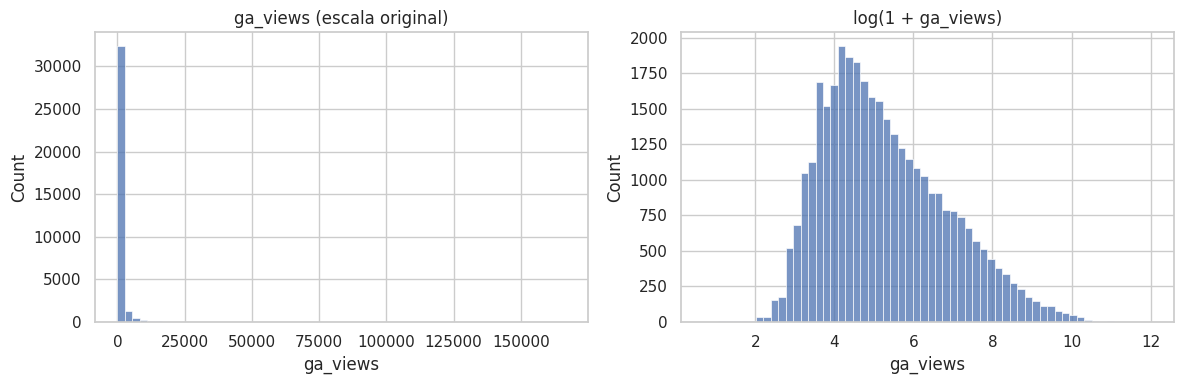

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['ga_views'], bins=60, ax=axes[0])
axes[0].set_title('ga_views (escala original)')

sns.histplot(np.log1p(df['ga_views']), bins=60, ax=axes[1])
axes[1].set_title('log(1 + ga_views)')
plt.tight_layout()
plt.show()

Vemos en la gráfica de la izquierda, `ga_views` en su escala original, se ve pegada al cero porque unas pocas notas virales estiran el eje. 

A la derecha,`ga_views` en `log(1+x)` para comprimir los valores, así se aprecia mejor cómo se distribuye la mayoría de las notas, no solo los extremos.

In [14]:
# Valores atípicos por categoría (regla IQR sobre log(ga_views), ya que la escala original
# está muy sesgada y marcaría como "atípico" casi cualquier nota exitosa)
df['log_ga_views'] = np.log1p(df['ga_views'])

def marca_atipicos(grupo):
    q1, q3 = grupo.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (grupo < q1 - 1.5 * iqr) | (grupo > q3 + 1.5 * iqr)

df['atipico'] = df.groupby('categoria')['log_ga_views'].transform(marca_atipicos)
print(f'Notas marcadas como atípicas: {df["atipico"].sum()} de {len(df)} ({df["atipico"].mean():.2%})')
print(df.groupby('categoria')['atipico'].mean().sort_values(ascending=False).round(3))

Notas marcadas como atípicas: 634 de 34728 (1.83%)
categoria
Las Destacadas    0.060
Finanzas          0.048
Tecnociencia      0.041
Sociedad          0.034
Internacional     0.032
Estado            0.024
Nacional          0.020
Espectáculos      0.020
Veracruz          0.003
Policiaca         0.001
Boca del Río      0.000
Name: atipico, dtype: float64


In [15]:
# No eliminamos los atípicos. Los "atípicos" de alto tráfico son justo las notas virales que más le pueden interesar al Director Editorial, no son ruido.
# Solo se dejan marcados para poder inspeccionarlos/excluirlos puntualmente si hiciera falta.

print('=== Top 10 notas con MAYOR tráfico (ga_views) ===')
display(df.nlargest(10, 'ga_views')[['titulo', 'categoria', 'nombre', 'ga_views']])



=== Top 10 notas con MAYOR tráfico (ga_views) ===


,titulo,categoria,nombre,ga_views
29724,Suprema Corte elimina el doble pago de pensión...,Nacional,Marcelo Brocado,166552.0
14782,Le quitaron su pensión del IMSS porque una per...,Veracruz,Inés Tompson,158852.0
21326,"Adulto mayor lleva 3 años sin cobrar pensión, ...",Veracruz,Inés Tompson,105027.0
28781,¿A que hora del miércoles serían las rachas má...,Veracruz,Alonso Fuentes,85707.0
21780,Cambian requisitos para sacar una casa con Inf...,Nacional,Alexandra Bagel,67859.0
15708,"Si los ves no les des de comer, muerden; coloc...",Veracruz,José de Alba,59516.0
30631,PC Veracruz prevé ingreso de nuevo frente frío...,Boca del Río,Javier Duque,57774.0
27765,Director de Costco considera 'absurdos' los cr...,Nacional,Alonso Fuentes,55030.0
32467,¿Cuándo y cómo deben hacer jubilados el nuevo ...,Nacional,Daniella Orozco,54080.0
27777,Filtran video del accidente en que perdió la v...,Policiaca,Alonso Fuentes,49212.0


In [16]:
print('\n=== Top 10 notas con MENOR tráfico (ga_views) ===')
display(df.nsmallest(10, 'ga_views')[['titulo', 'categoria', 'nombre', 'ga_views']])


=== Top 10 notas con MENOR tráfico (ga_views) ===


,titulo,categoria,nombre,ga_views
5230,Balacera en estacionamiento de supermercado de...,Policiaca,José Antonio Cabrera,1.0
6373,"Mujer es mordida por un cocodrilo, en Florida",Internacional,José de Alba,1.0
28676,Participación ciudadana en elecciones argentin...,Internacional,Alonso Fuentes,1.0
13190,Diputados piden reunión con congresistas de EU...,Nacional,Alonso Fuentes,2.0
14371,Economía de EU retrocede 0.2% en enero-marzo,Finanzas,Daniella Orozco,2.0
16788,Diputados discuten hoy martes reforma para que...,Nacional,Daniella Orozco,2.0
29662,Conoce la importancia de vacunar a tu mascota ...,Tecnociencia,Javier Duque,2.0
358,Papa Francisco pide respeto al derecho humanit...,Internacional,Daniella Orozco,3.0
4594,Hoy vence el plazo para la incorporación a la ...,Veracruz,Beatriz Olga Prado,3.0
7631,Sheinbaum asegura que cooperación fronteriza c...,Nacional,Alexandra Bagel,3.0


                   n  mediana        media    p40
categoria                                        
Boca del Río    2301    825.0  2542.391569  541.0
Veracruz        6175    512.0  1655.619757  347.6
Policiaca       4566    372.5  1172.409768  249.0
Estado          4861    128.0   642.007612   95.0
Nacional        6198     97.0   379.983382   73.0
Espectáculos    2011     87.0   388.630532   63.0
Sociedad         767     85.0   307.552803   69.0
Las Destacadas   799     76.0   331.222778   59.2
Tecnociencia    1234     60.0   165.838736   47.0
Internacional   4685     57.0   196.982497   45.0
Finanzas        1131     33.0    71.932803   29.0


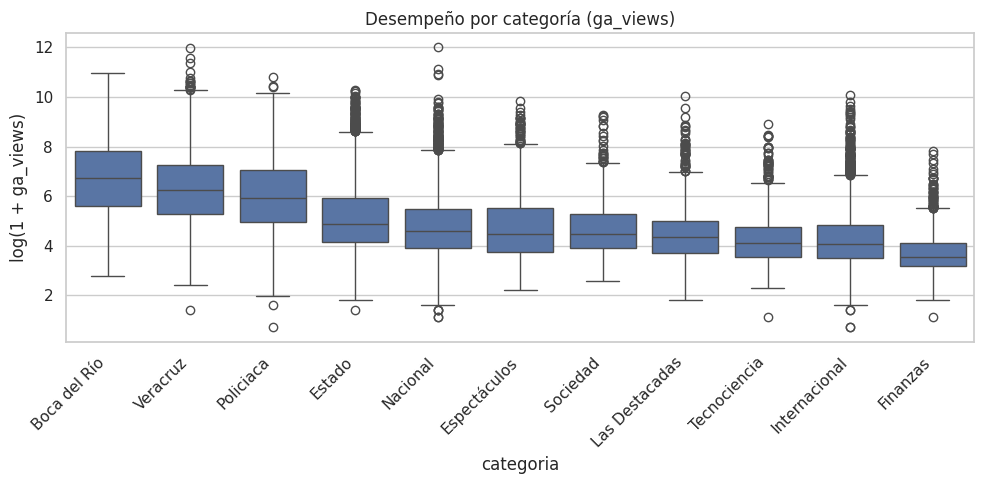

In [17]:
#Desempeño por categoría (ga_views)

resumen_categoria = (
    df.groupby('categoria')['ga_views']
    .agg(n='count', mediana='median', media='mean', p40=lambda s: s.quantile(0.40))
    .sort_values('mediana', ascending=False)
)
print(resumen_categoria)

plt.figure(figsize=(10, 5))
orden = df.groupby('categoria')['ga_views'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='categoria', y=np.log1p(df['ga_views']), order=orden)
plt.xticks(rotation=45, ha='right')
plt.ylabel('log(1 + ga_views)')
plt.title('Desempeño por categoría (ga_views)')
plt.tight_layout()
plt.show()

Categorías ordenadas de mayor a menor mediana, entre más arriba/a la izquierda, mejor desempeño típico. Los outliers aparecen en casi todas las categorías, incluso en las de mediana baja como Estado o Nacional, señal de que cualquier categoría puede producir una nota viral ocasional, pero eso no cambia su comportamiento típico.

In [18]:
resumen_autor = (
    df.groupby('nombre')['ga_views']
    .agg(n='count', mediana='median', media='mean')
    .sort_values('mediana', ascending=False)
)
print(resumen_autor)

# Nombre tiene solo 14 valores.
# Lo usamos como feature de contexto editorial, no lo expondremos
# en el dashboard como "factor de riesgo" atribuible a la persona.

                         n  mediana        media
nombre                                          
José de Alba           928    548.5  1716.727371
Joel Cervantes         844    484.5  1725.503555
Beatriz Olga Prado     747    465.0  1888.884873
Anabel Valencia       1426    313.0  1450.384993
Luis Lima Romero      1086    282.5   909.624309
Inés Tompson          1854    281.5  1157.240561
Marcelo Brocado       2461    154.0   617.631451
Daniella Orozco       6206    123.0   670.389140
Alonso Fuentes        5095    120.0   898.062610
José Antonio Cabrera   498    117.0   876.734940
Alexandra Bagel       4958    111.0   785.304962
Javier Duque          7723    110.0   639.825197
Paco Montiel           730     86.5   242.520548
Sofía Valenzuela       172     46.0   156.412791


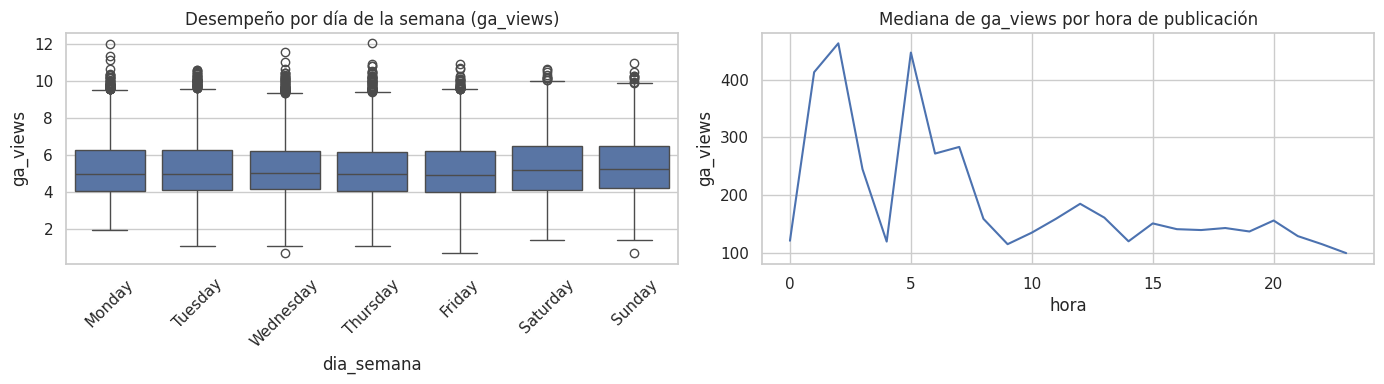

In [19]:
df['dia_semana'] = df['fecha'].dt.day_name()
df['hora'] = df['fecha'].dt.hour

orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=df, x='dia_semana', y=np.log1p(df['ga_views']), order=orden_dias, ax=axes[0])
axes[0].set_title('Desempeño por día de la semana (ga_views)')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=df.groupby('hora')['ga_views'].median().reset_index(), x='hora', y='ga_views', ax=axes[1])
axes[1].set_title('Mediana de ga_views por hora de publicación')

plt.tight_layout()
plt.show()

In [20]:
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Resumen por día de la semana (publicación, no visita)
resumen_dia = df.groupby('dia_semana')['ga_views'].agg(n='count', mediana='median', media='mean').reindex(orden_dias)
resumen_dia['es_finde'] = ['Finde' if d in ('Saturday', 'Sunday') else 'Entre semana' for d in resumen_dia.index]
print('=== Por día de la semana ===')
print(resumen_dia.round(1))

print()
print('=== Agregado entre semana vs. fin de semana ===')
print(resumen_dia.groupby('es_finde')[['n', 'mediana', 'media']].mean().round(1))

# Verificar que el efecto se sostiene por categoría, no solo en el agregado
df['es_finde'] = df['dia_semana'].isin(['Saturday', 'Sunday'])
por_categoria = df.groupby(['categoria', 'es_finde'])['ga_views'].median().unstack()
por_categoria.columns = ['entre_semana', 'finde']
por_categoria['finde_mayor'] = por_categoria['finde'] > por_categoria['entre_semana']
print()
print('=== Por categoría: ¿el finde rinde más? ===')
print(por_categoria.round(1))

# Descartar el sesgo de "las notas de finde son más viejas y tuvieron más tiempo de acumular vistas"
df['dias_expuesta'] = (df['visitasFechaUltima'] - df['fecha']).dt.days
print()
print('=== Recencia y tiempo de exposición (descartar sesgo) ===')
print('Fecha de publicación promedio:')
print(df.groupby('es_finde')['fecha'].mean())
print()
print('Días de exposición (última visita - publicación):')
print(df.groupby('es_finde')['dias_expuesta'].agg(['median', 'mean']).round(1))

print()
print('=== Por hora de publicación ===')
resumen_hora = df.groupby('hora')['ga_views'].agg(n='count', mediana='median')
print(resumen_hora)


=== Por día de la semana ===
               n  mediana  media      es_finde
dia_semana                                    
Monday      5385    141.0  888.2  Entre semana
Tuesday     5581    139.0  852.6  Entre semana
Wednesday   5355    153.0  795.7  Entre semana
Thursday    5496    139.0  825.1  Entre semana
Friday      5421    132.0  777.3  Entre semana
Saturday    3696    173.0  944.7         Finde
Sunday      3794    187.5  883.3         Finde

=== Agregado entre semana vs. fin de semana ===
                   n  mediana  media
es_finde                            
Entre semana  5447.6    140.8  827.8
Finde         3745.0    180.2  914.0

=== Por categoría: ¿el finde rinde más? ===
                entre_semana  finde  finde_mayor
categoria                                       
Boca del Río           786.0  989.0         True
Espectáculos            87.0   88.0         True
Estado                 123.0  157.5         True
Finanzas                31.0   63.5         True
Internaciona

A la izquierda, desempeño según el día de la semana en que se **publicó** la nota (no el día en que llegaron las visitas, eso no lo sabemos, `ga_views` es el total acumulado en la vida de la nota); a la derecha, mediana de vistas por hora de publicación.

- **Las notas publicadas en sábado o domingo acumulan, en promedio, más vistas totales a lo largo de su vida útil que las publicadas entre semana** (mediana 180 vs 141; media 914 vs 828). Se sostiene en 9 de 11 categorías y no se explica por que esas notas sean "más viejas", la fecha promedio de publicación y el tiempo de exposición son prácticamente iguales entre ambos grupos.
- Esto pasa **a pesar de que se publican menos notas en fin de semana** (3,745 en promedio vs 5,447 entre semana), no es un efecto de "menos competencia", cada nota individual rinde más.
- **Cuidado con los picos de la gráfica de horas, son ruido estadístico, no un patrón real**: los picos altísimos en la madrugada (1am, 2am, 5am, con medianas de 400+) vienen de horas con **casi nada de datos** (entre 3 y 27 notas publicadas, contra 900–3,000 en horas normales). Con muestras tan chicas, una o dos notas con suerte inflan la mediana.
- **El patrón confiable está en las horas con volumen real** (6am–11pm): mejor desempeño en la mañana (pico 283 a las 7am), bajando gradualmente hacia la noche (mínimo 100–120 entre 9pm y 11pm).


 A la izquierda, cuántas notas se publican cada día (entre semana se publica más: 5,400 notas por día vs. 3,700 en fin de semana). A la derecha, la mediana de vistas según el día en que se **publicó** la nota (no el día en que llegaron las visitas, eso no lo sabemos, `ga_views` es el total acumulado en la vida de la nota).

- **Las notas publicadas en fin de semana acumulan más vistas** (sábado 173, domingo 188) que las de entre semana (132-153), a pesar de que se publican menos ese día, no por "menos competencia": cada nota individual rinde más.
- No es un efecto de que esas notas sean más viejas y hayan tenido más tiempo de acumular vistas , la fecha promedio de publicación y el tiempo de exposición son prácticamente iguales entre ambos grupos .


### 4.2 Gráficas



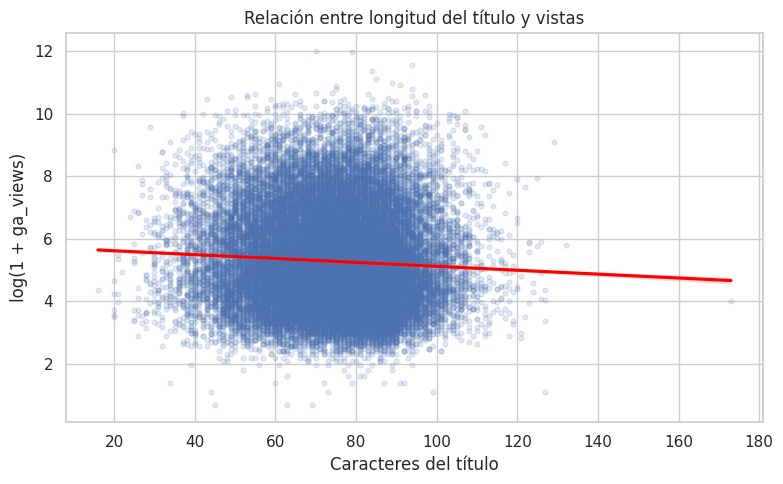

In [21]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df, x='caracteres_titulo', y='log_ga_views',
    scatter_kws={'alpha': 0.15, 's': 12}, line_kws={'color': 'red'},
)
plt.xlabel('Caracteres del título')
plt.ylabel('log(1 + ga_views)')
plt.title('Relación entre longitud del título y vistas')
plt.tight_layout()
plt.show()

Cada punto es una nota; la línea roja es la tendencia general entre longitud del título y desempeño. Una pendiente casi plana como esta confirma que la longitud del título por sí sola no predice bien el resultado .

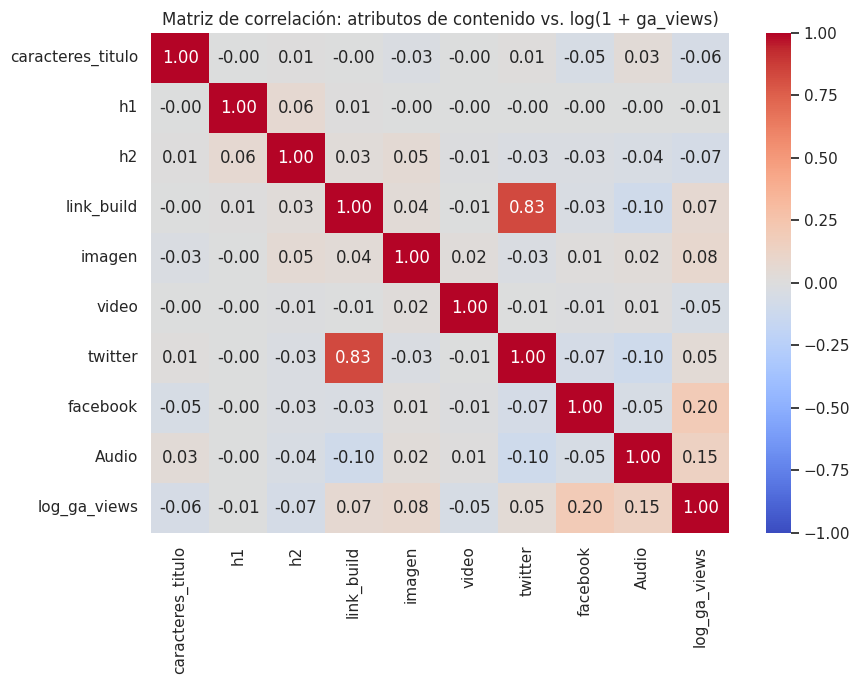

facebook             0.198748
Audio                0.146827
imagen               0.078494
link_build           0.066833
twitter              0.046320
h1                  -0.005495
video               -0.049295
caracteres_titulo   -0.058003
h2                  -0.068562
Name: log_ga_views, dtype: float64


In [22]:
atributos = ['caracteres_titulo', 'h1', 'h2', 'link_build', 'imagen', 'video', 'twitter', 'facebook', 'Audio']

# Matriz de correlación completa (heatmap) entre atributos de contenido y log_ga_views.
# Usamos log_ga_views (no ga_views crudo) por el mismo motivo de siempre: la escala
# original está muy sesgada y aplana artificialmente las correlaciones de Pearson.
matriz_corr = df[atributos + ['log_ga_views']].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Matriz de correlación: atributos de contenido vs. log(1 + ga_views)')
plt.tight_layout()
plt.show()

print(matriz_corr['log_ga_views'].drop('log_ga_views').sort_values(ascending=False))

- **Todas las correlaciones con `log_ga_views` son débiles** (máximo 0.20), ningún atributo de contenido por sí solo predice bien el desempeño. Los más fuertes son `facebook` (0.20), `Audio` (0.15) e `imagen` (0.08); el resto son prácticamente ruido.
- **`link_build` y `twitter` correlacionan 0.83 entre sí** , mucho más que cualquiera de los dos con `log_ga_views`. Esto es multicolinealidad, no una señal de desempeño: probablemente porque casi toda nota que trae una incrustación de Twitter también trae al menos un enlace (a la fuente citada o a la publicación original), así que en la práctica están midiendo casi lo mismo.
- Esto refuerza por qué no basta con mirar correlaciones individuales: el desempeño real depende de **combinaciones** de factores, no de una sola variable aislada , es justo lo que el modelo (y después SHAP) va a poder capturar y esta matriz no.

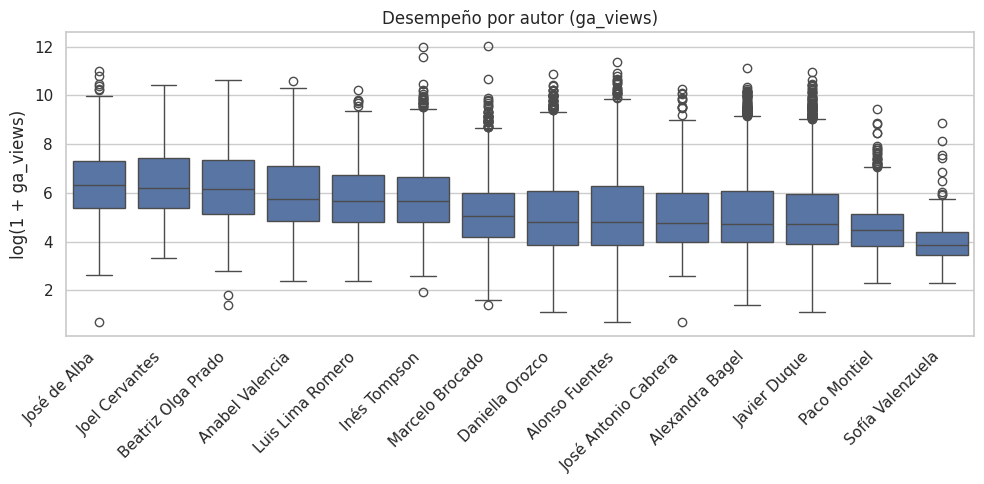

In [23]:
# Distribución de ga_views por autor (mismo criterio que categoría: orden por mediana)
plt.figure(figsize=(10, 5))
orden_autor = df.groupby('nombre')['ga_views'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='nombre', y=np.log1p(df['ga_views']), order=orden_autor)
plt.xticks(rotation=45, ha='right')
plt.ylabel('log(1 + ga_views)')
plt.xlabel('')
plt.title('Desempeño por autor (ga_views)')
plt.tight_layout()
plt.show()

Igual que el boxplot de categoría, pero por periodista, cada caja es la distribución de vistas de las notas de un autor.

- **La brecha entre el mejor y el peor autor es enorme**: casi **12 veces** de diferencia entre la mediana del autor con más tráfico y la del autor con menos, mucho más marcada que la brecha entre categorías.
- **Los tamaños de muestra varían mucho** (de 170 a más de 7,700 notas por autor), antes de sacar conclusiones fuertes sobre un autor específico vale la pena revisar cuántas notas tiene, ya que con pocas notas la mediana es menos confiable.
- Los "racimos" de puntos (outliers) arriba de cada caja no son señal de que ese autor sea más "volátil", son un efecto del tamaño de muestra. Los autores con más notas publicadas (los de la mitad para abajo en la gráfica, con miles de notas) simplemente tienen más oportunidades estadísticas de que salga un outlier, aunque su comportamiento típico no sea más errático. Por eso se ve una nube densa de círculos en esa zona y casi nada en los autores de arriba con menos notas.

- Los dos autores con peor mediana son justo los que tienen menos notas publicadas (en tu corrida real, serían los equivalentes a 170 y 730 notas, contra miles de los demás). 


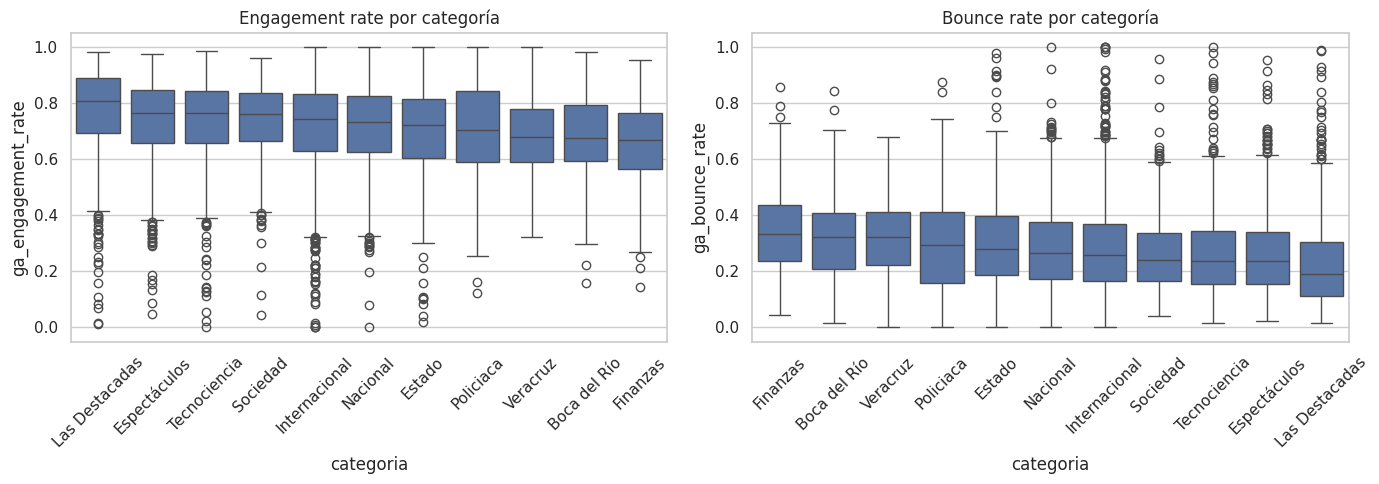

In [24]:
# Engagement rate y bounce rate por categoría, calidad de la visita, no solo volumen.
# Una categoría puede tener muchas vistas pero mala calidad de engagement (bounce alto), o viceversa.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orden_engagement = df.groupby('categoria')['ga_engagement_rate'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='categoria', y='ga_engagement_rate', order=orden_engagement, ax=axes[0])
axes[0].set_title('Engagement rate por categoría')
axes[0].tick_params(axis='x', rotation=45)

orden_bounce = df.groupby('categoria')['ga_bounce_rate'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='categoria', y='ga_bounce_rate', order=orden_bounce, ax=axes[1])
axes[1].set_title('Bounce rate por categoría')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Engagement rate y bounce rate miden *calidad* de la visita, no volumen, una categoría puede tener muchas vistas pero mala calidad (bounce alto), o pocas vistas pero muy buena calidad. Vemoq que prácticamente son espejo una de la otra (correlación de -1.0): `engagement_rate ≈ 1 - bounce_rate`, así que en la práctica cuentan la misma historia desde dos ángulos.

- **Las categorías con más tráfico no son las de mejor calidad**: Boca del Río, Veracruz y Policiaca (las 3 con más vistas del boxplot) están entre las de *menor* engagement y *mayor* bounce aquí.
- **Las Destacadas** tiene el mejor engagement (mediana 0.81) y el bounce más bajo (0.19), pese a no ser una categoría de alto volumen.
- Esto confirma que volumen y calidad de engagement son señales distintas.

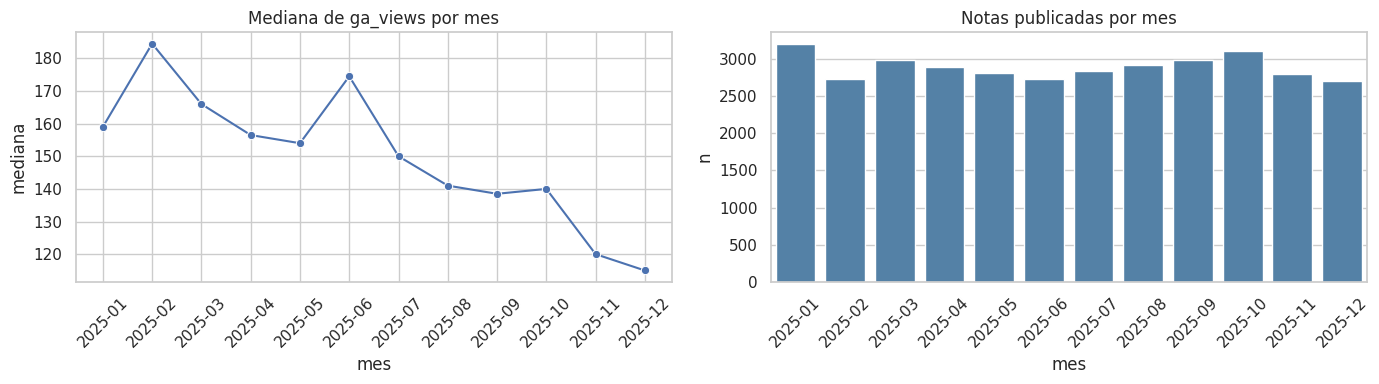

In [25]:
# Serie de tiempo mensual: ¿hay estacionalidad o tendencia a lo largo del año?
df['mes'] = df['fecha'].dt.to_period('M').astype(str)

resumen_mensual = df.groupby('mes')['ga_views'].agg(mediana='median', total='sum', n='count').reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.lineplot(data=resumen_mensual, x='mes', y='mediana', marker='o', ax=axes[0])
axes[0].set_title('Mediana de ga_views por mes')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=resumen_mensual, x='mes', y='n', ax=axes[1], color='steelblue')
axes[1].set_title('Notas publicadas por mes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

A la izquierda, la mediana de vistas por nota cada mes (para ver si hay tendencia o estacionalidad); a la derecha, cuántas notas se publicaron cada mes, para descartar que un "mes bueno" sea solo un mes con menos competencia por menos publicaciones.

- **Tendencia a la baja durante el año**: la mediana cae de 184 vistas en febrero (el pico) a 115 en diciembre. Incluso de enero a diciembre, sin contar el pico.
- **No es un efecto de volumen de publicación**: el número de notas por mes se mantiene estable todo el año (entre 2,708 y 3,199), sin picos ni caídas que expliquen la tendencia, la correlación entre volumen publicado y mediana de vistas es prácticamente cero (-0.001).
- Esto sugiere que la caída de tráfico responde a algo externo (estacionalidad del interés del público, cambios en el algoritmo de distribución, etc.) y no a que el medio haya publicado más o menos .

### 4.3 KPIs (indicadores del proyecto)


In [26]:
# "Alto rendimiento" = top 20% (p80) de ga_views dentro de su categoría (mismo criterio
# relativo por categoría que usaremos para el target de "bajo desempeño").
umbral_alto = df.groupby('categoria')['ga_views'].transform(lambda s: s.quantile(0.80))
noticias_alto_rendimiento = (df['ga_views'] >= umbral_alto)

kpis = {
    'Vistas por noticia (mediana)': df['ga_views'].median(),
    'Vistas por noticia (media)': df['ga_views'].mean(),
    'Engagement rate (media)': df['ga_engagement_rate'].mean(),
    'Notas de alto rendimiento (top 20% de su categoría)': f'{noticias_alto_rendimiento.sum()} ({noticias_alto_rendimiento.mean():.1%})',
}

for k, v in kpis.items():
    print(f'{k}: {v}')

Vistas por noticia (mediana): 148.0
Vistas por noticia (media): 846.39466712739
Engagement rate (media): 0.7086323450527751
Notas de alto rendimiento (top 20% de su categoría): 6960 (20.0%)


### Hallazgos del EDA

- `ga_views` está muy sesgada a la derecha (unos pocos artículos concentran la mayoría de las vistas), trabajamos en log-escala para visualizar y para definir el umbral.
- **El efecto de categoría es grande**, la mediana de `ga_views` varía mucho entre categorías (de 33 en Finanzas a 825 en Boca del Río). Un umbral global de "bajo desempeño" penalizaría siempre a las mismas categorías; por eso el umbral debe ser relativo a cada categoría.
- **El efecto de autor también es grande**, confirma la necesidad de tratarlo con cuidado ético .
- **Los atributos de contenido sí muestran relación con el desempeño una vez que usamos `ga_views`:** `facebook` (0.20), `Audio` (0.15) e `imagen` (0.08) tienen la correlación más fuerte con `log(1+ga_views)`. Son señales más útiles de lo que parecían con la métrica anterior, buenos candidatos para las recomendaciones accionables del dashboard.

## 5. Definición de la variable objetivo, Riesgo de bajo desempeño

Definimos **"bajo desempeño"** como estar por debajo del percentil 40 de `ga_views` **dentro de la misma categoría** (no un umbral global). Esto:
- Evita castigar categorías con audiencia naturalmente más chica (Internacional, Finanzas) frente a las grandes (Boca del Río, Veracruz).
- Da una etiqueta interpretable para el Director Editorial: "esta nota está en el 40% de menor desempeño de su sección", no un número absoluto sin contexto.
- Produce una proporción de clases razonable (40% bajo desempeño / 60% buen desempeño), ni extremadamente desbalanceado ni artificialmente 50/50.
- Es coherente con "Notas de alto rendimiento" del bloque de KPIs (mismo criterio relativo por categoría, solo que en el otro extremo: p80 en vez de p40).

 **Importante (fuga de información):** el sistema debe evaluar la nota *antes* de publicarse, así que `ga_views` y todas las demás columnas `ga_*` **solo se usan para construir el target**,no como features de entrada del modelo .

In [27]:
UMBRAL_PERCENTIL = 0.40

umbral_por_categoria = df.groupby('categoria')['ga_views'].transform(lambda s: s.quantile(UMBRAL_PERCENTIL))
df['bajo_desempeno'] = (df['ga_views'] < umbral_por_categoria).astype(int)

print('Distribución global de la clase (1 = bajo desempeño):')
print(df['bajo_desempeno'].value_counts(normalize=True).round(3))
print()
print('Proporción de "bajo desempeño" por categoría (debe rondar 0.40 en todas):')
print(df.groupby('categoria')['bajo_desempeno'].mean().round(3).sort_values())

Distribución global de la clase (1 = bajo desempeño):
bajo_desempeno
0    0.603
1    0.397
Name: proportion, dtype: float64

Proporción de "bajo desempeño" por categoría (debe rondar 0.40 en todas):
categoria
Finanzas          0.387
Tecnociencia      0.392
Espectáculos      0.394
Nacional          0.395
Internacional     0.396
Estado            0.398
Sociedad          0.398
Boca del Río      0.400
Policiaca         0.400
Veracruz          0.400
Las Destacadas    0.401
Name: bajo_desempeno, dtype: float64


## 6. Guardar el dataset limpio

Guardamos el dataset ya limpio, cruzado y con el target definido (`bajo_desempeno`) en un CSV. Este archivo (`datos/articulos_limpio.csv`) es el artefacto que usará el resto del pipeline , no vuelven a leer ni reprocesar los CSV originales de CMS/GA4.

In [28]:
# 'nota' es HTML crudo y pesado; lo dejamos fuera del CSV limpio .
OUTPUT_PATH = DATA_DIR / 'articulos_limpio.csv'
columnas_a_guardar = [c for c in df.columns if c != 'nota']

df[columnas_a_guardar].to_csv(OUTPUT_PATH, index=False)

# Verificación: re-leer el archivo para confirmar que se guardó bien
check = pd.read_csv(OUTPUT_PATH)
print(f'Archivo guardado en: {OUTPUT_PATH}')
print(f'Filas: {len(check):,} | Columnas: {check.shape[1]} | bajo_desempeno=1: {check["bajo_desempeno"].sum():,}')

Archivo guardado en: datos/articulos_limpio.csv
Filas: 34,728 | Columnas: 32 | bajo_desempeno=1: 13,795


In [29]:
check.head(3)

,id,titulo,caracteres_titulo,categoria,nombre,fecha,visitasFechaUltima,URL,h1,h2,link_build,imagen,video,twitter,facebook,Audio,join_key,ga_views,ga_active_users,ga_event_count,ga_key_events,ga_revenue,ga_engagement_rate,ga_bounce_rate,log_ga_views,atipico,dia_semana,hora,es_finde,dias_expuesta,mes,bajo_desempeno
0,1355202,Con baile y pirotecnia despiden al 2024 en el ...,66,Veracruz,José Antonio Cabrera,2025-01-01 00:14:00,2026-07-22 10:52:35,veracruz/1355202/con-baile-y-pirotecnia-despid...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,/veracruz/1355202/con-baile-y-pirotecnia-despi...,339.0,295.0,3444.0,122.0,3.750624,0.780564,0.219436,5.828946,False,Wednesday,0,False,567,2025-01,1
1,1355203,Con desfile y pirotecnia reciben el Año Nuevo ...,77,Boca del Río,José Antonio Cabrera,2025-01-01 02:01:00,2026-07-21 19:42:44,boca-del-rio/1355203/con-desfile-y-pirotecnia-...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,/boca-del-rio/1355203/con-desfile-y-pirotecnia...,1100.0,931.0,11159.0,546.0,22.352247,0.747485,0.252515,7.003974,False,Wednesday,2,False,566,2025-01,0
2,1355204,Desfiles para despedir El Viejo serán cada año...,86,Boca del Río,José Antonio Cabrera,2025-01-01 02:11:00,2026-07-24 16:48:52,boca-del-rio/1355204/desfiles-para-despedir-el...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,/boca-del-rio/1355204/desfiles-para-despedir-e...,422.0,366.0,4204.0,232.0,6.344271,0.704261,0.295739,6.047372,False,Wednesday,2,False,569,2025-01,1


## 7. Ingeniería de Variables

Organizado en las 3 fases de tu planeación.

### Fase 1 (Variables editoriales)

Ya calculadas en secciones anteriores: `categoria`, `nombre`, `caracteres_titulo`, `imagen`, `video`, `hora`, `dia_semana`. Faltan tres piezas de longitud que agregamos aquí:
- **Palabras del título** (no solo caracteres).
- **Longitud del contenido** (`palabras_cuerpo`) y **número de párrafos** (`parrafos_cuerpo`), releyendo `nota` del CMS original solo para esto (columnas `id` + `nota`, no las 18 completas), el HTML crudo no se vuelve a guardar en ningún archivo.


In [30]:
df['palabras_titulo'] = df['titulo'].str.split().str.len()
print(df['palabras_titulo'].describe())
print('\nCorrelación con log_ga_views:', df['palabras_titulo'].corr(df['log_ga_views']).round(3))

count    34728.000000
mean        12.125979
std          2.630770
min          3.000000
25%         10.000000
50%         12.000000
75%         14.000000
max         27.000000
Name: palabras_titulo, dtype: float64

Correlación con log_ga_views: -0.016


In [31]:
# Releemos 'nota' (HTML crudo) directo del CMS original, solo columnas id+nota,
# no se guardó en articulos_limpio.csv por pesada, así que hay que ir por ella aquí
# para calcular palabras_cuerpo (longitud real del texto, sin etiquetas) y
# parrafos_cuerpo (número de <p> con texto real).
import html as html_lib
import re

nota_df = pd.read_csv(CMS_PATH, encoding='latin-1', usecols=['id', 'nota'])

def quitar_embeds(texto_html):
    # Los <blockquote> de Twitter/X traen el texto real del tuit adentro (no es
    # contenido editorial), se quita ANTES de contar palabras/párrafos, para no
    # contar el tuit como si lo hubiera escrito el redactor (afecta a 4,673 notas,
    # mediana de 46 'palabras' de más si no se filtra).
    return re.sub(r'<blockquote.*?</blockquote>', ' ', str(texto_html), flags=re.DOTALL | re.IGNORECASE)

def contar_palabras(texto_html):
    texto = quitar_embeds(texto_html)
    texto = re.sub(r'<[^>]+>', ' ', texto)   # quitar etiquetas HTML
    texto = html_lib.unescape(texto)          # decodificar &oacute; etc.
    return len(texto.split())

def contar_parrafos_reales(html_texto):
    # Cuenta <p> con texto real adentro, ignorando los vacíos (<p>&nbsp;</p>) que
    # dejan pegados algunos widgets/embeds, esos vacíos eran los que disparaban
    # parrafos_cuerpo a valores absurdos (1,000+) en notas con muy pocas palabras
    # reales (visto en los ids 1359776 y 1365434).
    texto = quitar_embeds(html_texto)
    bloques = re.findall(r'<p[^>]*>(.*?)</p>', texto, flags=re.DOTALL | re.IGNORECASE)
    contador = 0
    for bloque in bloques:
        texto_plano_bloque = re.sub(r'<[^>]+>', ' ', bloque)
        texto_plano_bloque = html_lib.unescape(texto_plano_bloque)
        if texto_plano_bloque.strip():
            contador += 1
    return contador

nota_df['palabras_cuerpo'] = nota_df['nota'].apply(contar_palabras)
nota_df['parrafos_cuerpo'] = nota_df['nota'].apply(contar_parrafos_reales)

df = df.merge(nota_df[['id', 'palabras_cuerpo', 'parrafos_cuerpo']], on='id', how='left')

print('Nulos tras el merge:', df[['palabras_cuerpo', 'parrafos_cuerpo']].isna().sum().to_dict())
print()
print(df[['palabras_cuerpo', 'parrafos_cuerpo']].describe())
print()
print('Correlación con log_ga_views:')
print(df[['palabras_cuerpo', 'parrafos_cuerpo', 'log_ga_views']].corr()['log_ga_views'].drop('log_ga_views'))


Nulos tras el merge: {'palabras_cuerpo': 0, 'parrafos_cuerpo': 0}

       palabras_cuerpo  parrafos_cuerpo
count     34728.000000     34728.000000
mean        254.480333         6.137008
std         155.624601         4.325193
min          35.000000         0.000000
25%         148.000000         4.000000
50%         210.000000         5.000000
75%         318.000000         7.000000
max        3629.000000       122.000000

Correlación con log_ga_views:
palabras_cuerpo   -0.263856
parrafos_cuerpo    0.079425
Name: log_ga_views, dtype: float64


`palabras_cuerpo` tiene mediana de 210 palabras y `parrafos_cuerpo` de 5 . El máximo de `parrafos_cuerpo` (122) . La correlación confirma : `palabras_cuerpo` sí importa (-0.26, notas más largas rinden peor), mientras que `parrafos_cuerpo` por sí solo es una señal débil (0.08).

Los `<blockquote class="twitter-tweet">` traen el texto real del tuit adentro (hashtags, contenido, etc.),  `quitar_embeds()` (celda anterior) ya lo excluye antes de contar palabras y párrafos. 

**Casos atípicos detectados:** no es un criterio arbitrario, para saber cuáles notas eran "malas" ordenamos por `parrafos_cuerpo` (conteo crudo de `<p>`, antes de la corrección) de mayor a menor. Las primeras 5 se salen completamente de rango frente a sus propias `palabras_cuerpo` (cientos o miles de "párrafos" para textos de apenas 200-300 palabras). Revisamos el HTML de cada una y las 5 comparten el mismo patrón: widgets/embeds pegados que dejan cientos de `<p>&nbsp;</p>` vacíos, no es contenido editorial real. En vez de eliminarlas del dataset, se corrigió la causa raíz: `contar_parrafos_reales()` (celda anterior) ya ignora los `<p>` vacíos, así que las 5 quedan con un conteo real, sin necesidad de descartarlas.

In [32]:
# Evidencia de cómo se identificaron estos casos: ordenamos por el conteo CRUDO de <p>
# (recalculado aquí solo para mostrar el 'antes') contra el conteo ya corregido que
# quedó en df. Si contar_parrafos_reales() funcionó, la columna de la derecha debería
# verse muchísimo más razonable que la de la izquierda para estos 5 casos.
parrafos_crudo = df['nota'].apply(lambda t: str(t).count('<p'))

top5_atipicos = (
    df.assign(parrafos_crudo=parrafos_crudo)
    .nlargest(5, 'parrafos_crudo')
    [['id', 'titulo', 'palabras_cuerpo', 'parrafos_crudo', 'parrafos_cuerpo']]
    .rename(columns={
        'parrafos_crudo': 'parrafos_cuerpo (crudo, antes)',
        'parrafos_cuerpo': 'parrafos_cuerpo (corregido, ahora)',
    })
)
print(top5_atipicos.to_string(index=False))

print('\nNuevo máximo de parrafos_cuerpo en TODO el dataset (ya corregido):', df['parrafos_cuerpo'].max())

print('\nCorrelación con log_ga_views:')
print(df[['palabras_cuerpo', 'parrafos_cuerpo', 'log_ga_views']].corr()['log_ga_views'].drop('log_ga_views'))


     id                                                                titulo  palabras_cuerpo  parrafos_cuerpo (crudo, antes)  parrafos_cuerpo (corregido, ahora)
1359776 Reportan un motín en el penal de Villahermosa, Tabasco; hay 7 muertos              147                            1542                                   6
1365434   Revelan la causa de la muerte del reportero deportivo Adán Manzano               286                            1033                                   8
1355802            Trudeau anuncia su renuncia como primer ministro de Canadá              197                            1030                                   7
1395069   Niñ0s sicarios, resultado de los abrazos al crimen de AMLO: Añorve               267                             775                                   8
1395867                          CNTE toma casetas en autopistas y hace esto               198                             358                                   7

Nuevo máximo de parra

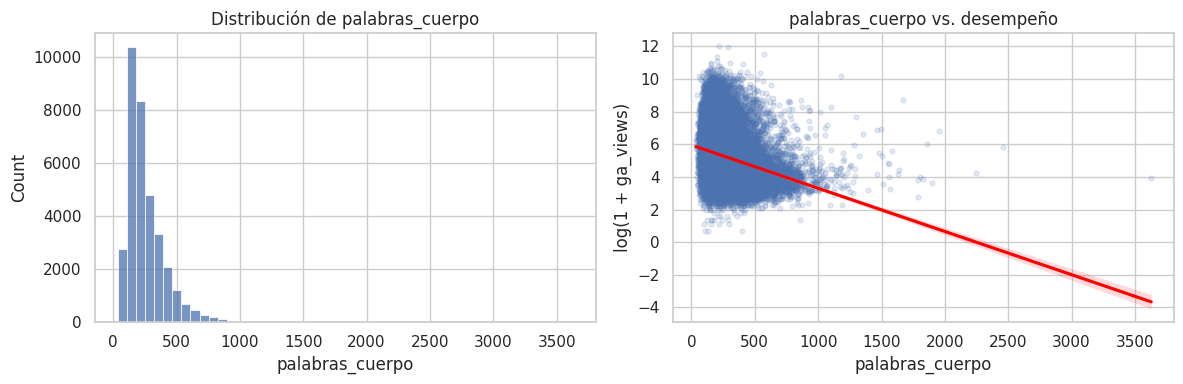

In [33]:
# Distribución de palabras_cuerpo y su relación con el desempeño (correlación -0.26)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['palabras_cuerpo'], bins=50, ax=axes[0])
axes[0].set_title('Distribución de palabras_cuerpo')

sns.regplot(
    data=df, x='palabras_cuerpo', y='log_ga_views',
    scatter_kws={'alpha': 0.15, 's': 12}, line_kws={'color': 'red'}, ax=axes[1],
)
axes[1].set_title('palabras_cuerpo vs. desempeño')
axes[1].set_ylabel('log(1 + ga_views)')

plt.tight_layout()
plt.show()

A la izquierda, cómo se reparte la longitud del cuerpo entre todas las notas, la mayoría se concentra entre 100 y 400 palabras, con una cola larga hacia la derecha (notas de hasta 3,600+ palabras, poco comunes). A la derecha, su relación con el desempeño, la línea roja con pendiente hacia abajo confirma que las notas más largas tienden a rendir peor (correlación -0.26), aunque la nube de puntos es ancha: la longitud influye, pero está lejos de ser el único factor.

In [34]:
print('Correlación caracteres_titulo vs log_ga_views:', df['caracteres_titulo'].corr(df['log_ga_views']).round(3))
print('Correlación palabras_titulo vs log_ga_views:', df['palabras_titulo'].corr(df['log_ga_views']).round(3))

Correlación caracteres_titulo vs log_ga_views: -0.058
Correlación palabras_titulo vs log_ga_views: -0.016


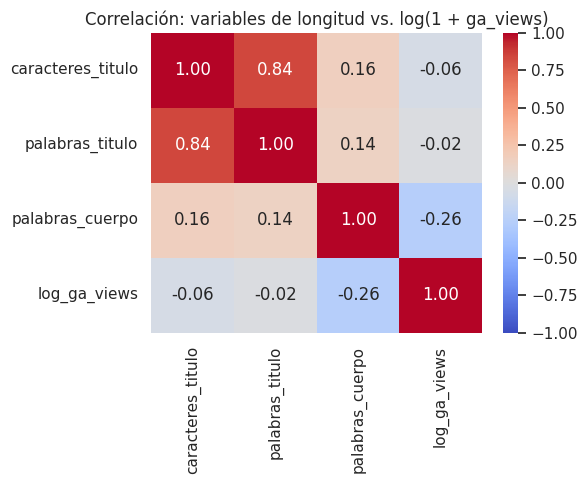

In [35]:
atributos_longitud = ['caracteres_titulo', 'palabras_titulo', 'palabras_cuerpo']

matriz_corr_longitud = df[atributos_longitud + ['log_ga_views']].corr(numeric_only=True)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_corr_longitud, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlación: variables de longitud vs. log(1 + ga_views)')
plt.tight_layout()
plt.show()

- **`caracteres_titulo` y `palabras_titulo` correlacionan 0.84 entre sí**, tiene sentido, un título con más caracteres casi siempre tiene más palabras, están midiendo casi lo mismo (longitud del título vista de dos formas). Por eso conviene interpretarlas juntas, no como dos señales independientes.
- **Ninguna de las dos correlaciona con `log_ga_views`** (-0.06 y -0.02, prácticamente cero): la longitud del título, medida en caracteres o en palabras, no predice el desempeño.
- **`palabras_cuerpo` es la única variable de esta tabla con una relación real** con el desempeño (-0.26): notas con cuerpos más largos tienden a rendir peor. Su correlación con las variables de título también es débil (0.16 y 0.14), así que no es redundante con ellas, mide algo distinto.

De las 3 variables de longitud, solo la del *cuerpo* importa para predecir desempeño; la longitud del *título* es prácticamente irrelevante en este dataset.

### Análisis exploratorio adicional: ¿importa el significado del título? (embeddings)

`caracteres_titulo` y `palabras_titulo` casi no correlacionan con el desempeño, a diferencia de `palabras_cuerpo`, que sí mostró una relación real (correlación
-0.26). Esto no significa que el título no importe, solo que **su longitud** no es la señal,
puede que lo que importe sea **de qué habla o cómo suena** el título, algo que un conteo de
caracteres no puede capturar.

Para explorar esto probamos *embeddings*: representaciones numéricas del significado del
texto (no de su longitud), generadas con un modelo de lenguaje pre-entrenado multilingüe. Si
el significado del título influye en el desempeño, los títulos "buenos" deberían agruparse de
forma distinta a los "malos" en este espacio.

**Importante:** esto es exploración, no una feature nueva del modelo. No modifica el pipeline
de entrenamiento ni el modelo ya validado, es una pregunta adicional que dejo documentada.

I0000 00:00:1785978284.986603  268822 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785978287.278784  268822 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Varianza explicada por las 2 componentes: 0.132


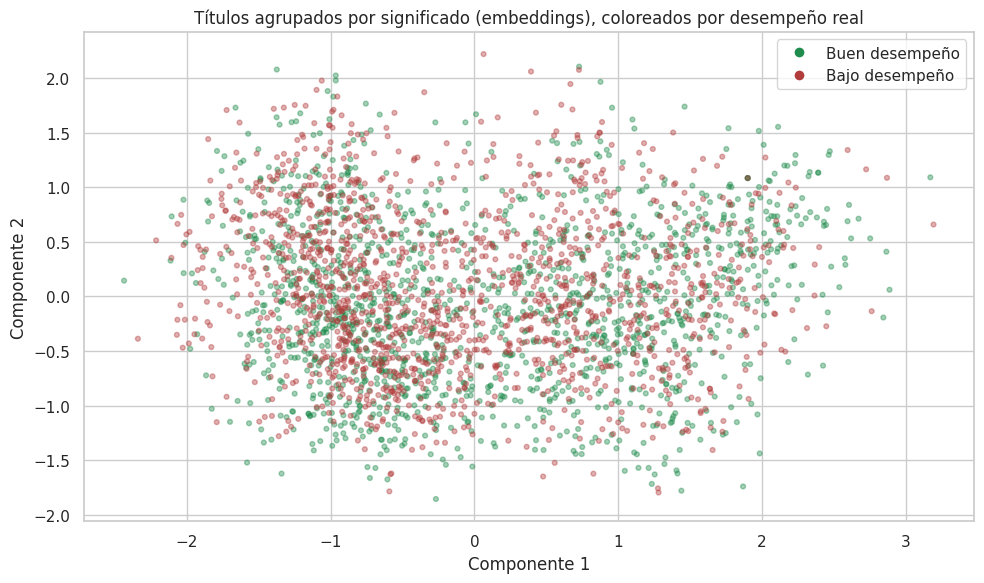

In [36]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

# Muestra balanceada (no todo el dataset, por tiempo de cómputo): 1500 títulos de cada
# clase, elegidos al azar con semilla fija .
muestra = df.groupby('bajo_desempeno', group_keys=False).sample(n=1500, random_state=42)

# device='cpu' explícito: este paso no necesita GPU (son títulos cortos, tarda segundos en
# CPU) y evita depender de que CUDA esté disponible/sano en el entorno donde se corra.
modelo_emb = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device='cpu')
embeddings = modelo_emb.encode(muestra['titulo'].tolist(), batch_size=64)

pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)
print('Varianza explicada por las 2 componentes:', pca.explained_variance_ratio_.sum().round(3))

plt.figure(figsize=(10, 6))
colores = muestra['bajo_desempeno'].map({0: '#1F8B4C', 1: '#B23B3B'})
plt.scatter(coords[:, 0], coords[:, 1], c=colores, alpha=0.4, s=12)
plt.title('Títulos agrupados por significado (embeddings), coloreados por desempeño real')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#1F8B4C', markersize=8, label='Buen desempeño'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#B23B3B', markersize=8, label='Bajo desempeño'),
]
plt.legend(handles=handles)
plt.tight_layout()
plt.show()


Cada punto es un título representado en un espacio de
significado reducido a 2 dimensiones; verde = buen desempeño, rojo = bajo desempeño. Si el
significado del título influyera en el desempeño, esperaríamos ver zonas donde predomina un
color.

Los colores aparecen mezclados sin un patrón visible, ni la longitud
(correlación ≈0) ni el significado superficial del título (embeddings, en esta proyección 2D)
explican el desempeño por sí solos. Estos 2 componentes solo capturan
13% de la información total de los embeddings (384 dimensiones), así que esto no descarta
por completo una señal más sutil en dimensiones que no se pueden graficar  pero sí indica
que, si existe, es débil. Es consistente con lo que ya vimos en el modelo: las señales fuertes
vienen de otro lado (categoría, multimedia, horario, longitud del cuerpo), no del título en sí.

### Fase 2 (Variables derivadas)

- **Longitud promedio de párrafo**: `palabras_cuerpo / parrafos_cuerpo`.
- **Tipo de contenido** (texto vs. multimedia): a partir de si la nota trae imagen, video o audio.
- **Clasificación de horario** (mañana/tarde/noche) a partir de `hora`.

In [37]:
# Longitud promedio de párrafo (evitando división por 0 cuando parrafos_cuerpo == 0)
df['longitud_promedio_parrafo'] = np.where(
    df['parrafos_cuerpo'] > 0,
    df['palabras_cuerpo'] / df['parrafos_cuerpo'],
    df['palabras_cuerpo'],  # si no hay <p>, tratamos todo el cuerpo como un solo "párrafo"
)

print(df['longitud_promedio_parrafo'].describe())
print('\nCorrelación con log_ga_views:', df['longitud_promedio_parrafo'].corr(df['log_ga_views']).round(3))

count    34728.000000
mean        66.191123
std         83.255233
min          3.927083
25%         26.875000
50%         33.750000
75%         49.333333
max       2461.000000
Name: longitud_promedio_parrafo, dtype: float64

Correlación con log_ga_views: -0.302


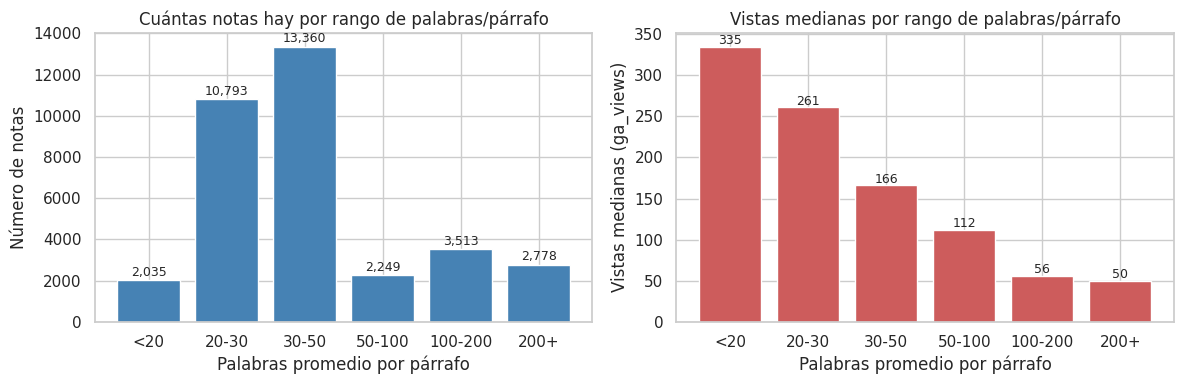

In [38]:
# Esta es la variable más importante según SHAP . Agrupamos en rangos simples de 'palabras por párrafo' y mostramos barras.
bins = [0, 20, 30, 50, 100, 200, 10000]
labels = ['<20', '20-30', '30-50', '50-100', '100-200', '200+']
df['rango_parrafo'] = pd.cut(df['longitud_promedio_parrafo'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

conteo = df['rango_parrafo'].value_counts().reindex(labels)
axes[0].bar(labels, conteo.values, color='steelblue')
axes[0].set_title('Cuántas notas hay por rango de palabras/párrafo')
axes[0].set_xlabel('Palabras promedio por párrafo')
axes[0].set_ylabel('Número de notas')
for i_bar, v in enumerate(conteo.values):
    axes[0].text(i_bar, v + 200, f'{v:,}', ha='center', fontsize=9)

mediana_vistas = df.groupby('rango_parrafo', observed=True)['ga_views'].median().reindex(labels)
axes[1].bar(labels, mediana_vistas.values, color='indianred')
axes[1].set_title('Vistas medianas por rango de palabras/párrafo')
axes[1].set_xlabel('Palabras promedio por párrafo')
axes[1].set_ylabel('Vistas medianas (ga_views)')
for i_bar, v in enumerate(mediana_vistas.values):
    axes[1].text(i_bar, v + 3, f'{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


A la izquierda, cuántas notas caen en cada rango de "palabras por párrafo" (la mayoría, tiene párrafos de entre 20 y 50 palabras). A la derecha, la mediana de vistas de las notas en cada rango.

- **La relación es perfectamente escalonada**: entre más largo el párrafo promedio, menos vistas, 335 vistas medianas para párrafos muy cortos (<20 palabras) hasta solo 50 para párrafos largos (200+ palabras). Es la relación más marcada de todo el EDA.
- En otras palabras: **dividir el texto en más párrafos, aunque sea la misma cantidad de palabras, está asociado a mejor desempeño**, probablemente porque es más fácil de leer en pantalla.

In [39]:
# Tipo de contenido: multimedia si trae imagen, video o audio; texto si no trae nada de eso.
tiene_multimedia = (df['imagen'] > 0) | (df['video'] > 0) | (df['Audio'].fillna(0) == 1)
df['tipo_contenido'] = np.where(tiene_multimedia, 'Multimedia', 'Texto')

print(df['tipo_contenido'].value_counts())
print()
print(df.groupby('tipo_contenido')['ga_views'].median())

tipo_contenido
Texto         25318
Multimedia     9410
Name: count, dtype: int64

tipo_contenido
Multimedia    245.0
Texto         121.0
Name: ga_views, dtype: float64


In [40]:
# Clasificación de horario: Mañana (6-11), Tarde (12-18), Noche (19-23 y 0-5)
def clasificar_horario(hora):
    if 6 <= hora <= 11:
        return 'Mañana'
    elif 12 <= hora <= 18:
        return 'Tarde'
    else:
        return 'Noche'

df['horario'] = df['hora'].apply(clasificar_horario)

print(df['horario'].value_counts())
print()
print(df.groupby('horario')['ga_views'].median().sort_values(ascending=False))

horario
Tarde     15678
Mañana    12117
Noche      6933
Name: count, dtype: int64

horario
Mañana    165.0
Tarde     145.0
Noche     131.0
Name: ga_views, dtype: float64


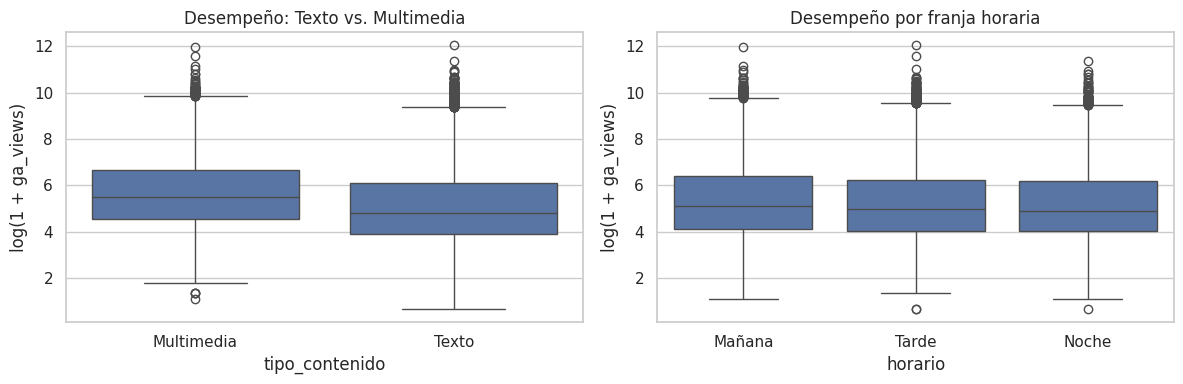

In [41]:
# Versión visual de los dos hallazgos que ya vimos como tablas: multimedia casi duplica
# las vistas medianas, y publicar en la mañana rinde mejor que en la noche.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='tipo_contenido', y='log_ga_views', ax=axes[0])
axes[0].set_title('Desempeño: Texto vs. Multimedia')
axes[0].set_ylabel('log(1 + ga_views)')

orden_horario = ['Mañana', 'Tarde', 'Noche']
sns.boxplot(data=df, x='horario', y='log_ga_views', order=orden_horario, ax=axes[1])
axes[1].set_title('Desempeño por franja horaria')
axes[1].set_ylabel('log(1 + ga_views)')

plt.tight_layout()
plt.show()

Cajas más arriba = mejor desempeño típico. A la izquierda, "Multimedia" queda claramente por encima de "Texto"; a la derecha, "Mañana" por encima de "Tarde" y "Noche", ambos confirman en formato visual los hallazgos que ya habíamos visto como tablas.



### Fase 3 (Variable objetivo y transformación)

- `bajo_desempeno` ya está definido (percentil 40 por categoría).
- Agregamos `alto_rendimiento` (percentil 80 por categoría) como columna, ya lo calculábamos como KPI, aquí lo dejamos persistido en el dataset.
- **Normalización, codificación de categóricas, eliminación de variables redundantes y selección de variables importantes NO se hacen aquí.** Van dentro del pipeline de modelado : normalizar/codificar antes de tiempo usando todo el dataset filtraría información de test hacia train (fuga de datos), y "selección de variables importantes" necesita un modelo ya entrenado (lo haremos con SHAP).

In [42]:
umbral_alto = df.groupby('categoria')['ga_views'].transform(lambda s: s.quantile(0.80))
df['alto_rendimiento'] = (df['ga_views'] >= umbral_alto).astype(int)

print(df['alto_rendimiento'].value_counts(normalize=True).round(3))
print()
print('Proporción de "alto rendimiento" por categoría (debe rondar 0.20 en todas):')
print(df.groupby('categoria')['alto_rendimiento'].mean().round(3).sort_values())

alto_rendimiento
0    0.8
1    0.2
Name: proportion, dtype: float64

Proporción de "alto rendimiento" por categoría (debe rondar 0.20 en todas):
categoria
Boca del Río      0.200
Espectáculos      0.200
Estado            0.200
Las Destacadas    0.200
Nacional          0.200
Policiaca         0.200
Veracruz          0.200
Internacional     0.201
Sociedad          0.201
Finanzas          0.202
Tecnociencia      0.202
Name: alto_rendimiento, dtype: float64


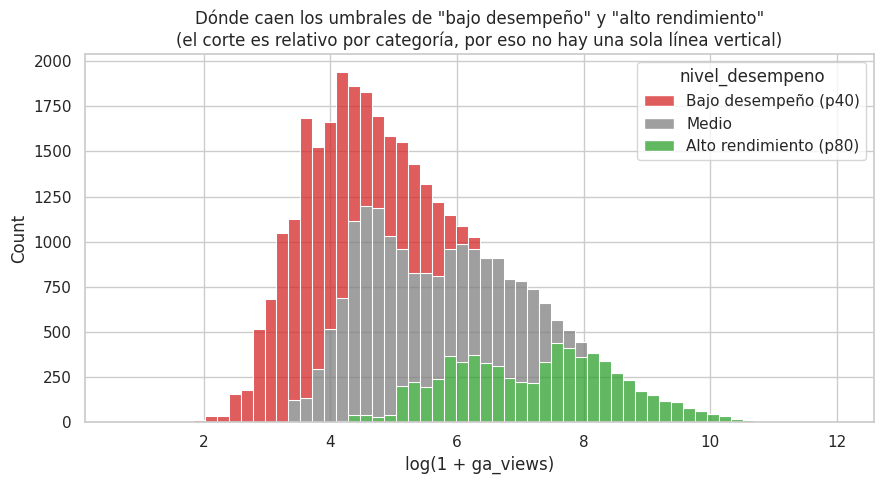

In [43]:
# Como el umbral es relativo por categoría (no un corte global), coloreamos cada nota
# según su nivel para ver cómo se reparten sobre la distribución completa de ga_views.
df['nivel_desempeno'] = np.select(
    [df['bajo_desempeno'] == 1, df['alto_rendimiento'] == 1],
    ['Bajo desempeño (p40)', 'Alto rendimiento (p80)'],
    default='Medio',
)

plt.figure(figsize=(9, 5))
sns.histplot(
    data=df, x='log_ga_views', hue='nivel_desempeno',
    hue_order=['Bajo desempeño (p40)', 'Medio', 'Alto rendimiento (p80)'],
    palette={'Bajo desempeño (p40)': '#d62728', 'Medio': '#7f7f7f', 'Alto rendimiento (p80)': '#2ca02c'},
    bins=60, multiple='stack',
)
plt.xlabel('log(1 + ga_views)')
plt.title('Dónde caen los umbrales de "bajo desempeño" y "alto rendimiento"\n(el corte es relativo por categoría, por eso no hay una sola línea vertical)')
plt.tight_layout()
plt.show()

Cada barra es un rango de `log_ga_views`; el color muestra qué proporción de esas notas cayó en cada nivel. No hay una sola línea de corte porque el umbral es relativo a la categoría de cada nota, por eso el rojo (bajo desempeño) y el verde (alto rendimiento) aparecen mezclados en varias zonas del eje, no solo en los extremos.

### Guardar el CSV con todas las variables de las 3 fases

Volvemos a guardar `articulos_limpio.csv`  con todas las variables de Fase 1, 2 y 3 ya calculadas, listo para el pipeline de modelado .

In [44]:
columnas_a_guardar = [c for c in df.columns if c != 'nota']
df[columnas_a_guardar].to_csv(OUTPUT_PATH, index=False)

check = pd.read_csv(OUTPUT_PATH)
print(f'Archivo actualizado en: {OUTPUT_PATH}')
print(f'Filas: {len(check):,} | Columnas: {check.shape[1]}')
print('palabras_cuerpo' in check.columns, 'parrafos_cuerpo' in check.columns)

Archivo actualizado en: datos/articulos_limpio.csv
Filas: 34,728 | Columnas: 41
True True


In [45]:
check.head(3)

,id,titulo,caracteres_titulo,categoria,nombre,fecha,visitasFechaUltima,URL,h1,h2,link_build,imagen,video,twitter,facebook,Audio,join_key,ga_views,ga_active_users,ga_event_count,ga_key_events,ga_revenue,ga_engagement_rate,ga_bounce_rate,log_ga_views,atipico,dia_semana,hora,es_finde,dias_expuesta,mes,bajo_desempeno,palabras_titulo,palabras_cuerpo,parrafos_cuerpo,longitud_promedio_parrafo,rango_parrafo,tipo_contenido,horario,alto_rendimiento,nivel_desempeno
0,1355202,Con baile y pirotecnia despiden al 2024 en el ...,66,Veracruz,José Antonio Cabrera,2025-01-01 00:14:00,2026-07-22 10:52:35,veracruz/1355202/con-baile-y-pirotecnia-despid...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,/veracruz/1355202/con-baile-y-pirotecnia-despi...,339.0,295.0,3444.0,122.0,3.750624,0.780564,0.219436,5.828946,False,Wednesday,0,False,567,2025-01,1,12,201,8,25.125000,20-30,Multimedia,Noche,0,Bajo desempeño (p40)
1,1355203,Con desfile y pirotecnia reciben el Año Nuevo ...,77,Boca del Río,José Antonio Cabrera,2025-01-01 02:01:00,2026-07-21 19:42:44,boca-del-rio/1355203/con-desfile-y-pirotecnia-...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,/boca-del-rio/1355203/con-desfile-y-pirotecnia...,1100.0,931.0,11159.0,546.0,22.352247,0.747485,0.252515,7.003974,False,Wednesday,2,False,566,2025-01,0,15,149,6,24.833333,20-30,Multimedia,Noche,0,Medio
2,1355204,Desfiles para despedir El Viejo serán cada año...,86,Boca del Río,José Antonio Cabrera,2025-01-01 02:11:00,2026-07-24 16:48:52,boca-del-rio/1355204/desfiles-para-despedir-el...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,/boca-del-rio/1355204/desfiles-para-despedir-e...,422.0,366.0,4204.0,232.0,6.344271,0.704261,0.295739,6.047372,False,Wednesday,2,False,569,2025-01,1,14,105,4,26.250000,20-30,Multimedia,Noche,0,Bajo desempeño (p40)


## 8. Modelado

Plan: (1) fijar la lista final de features (sin fuga de información) y el target, (2) separar train/test de forma estratificada, (3) armar el pipeline de normalización + codificación entrenado *solo* sobre train, (4) entrenar y comparar Logistic Regression, Random Forest, Gradient Boosting y XGBoost, (5) confirmar la comparación con validación cruzada estratificada (no depender de un solo split), (6) elegir el mejor con SHAP para explicar sus decisiones.

### 8.1 Features finales y target

In [46]:
FEATURES_NUMERICAS = [
    'caracteres_titulo', 'palabras_titulo', 'palabras_cuerpo', 'parrafos_cuerpo',
    'longitud_promedio_parrafo', 'h1', 'h2', 'link_build', 'imagen', 'video',
    'twitter', 'facebook', 'hora', 'Audio',
]
FEATURES_CATEGORICAS = ['categoria', 'nombre', 'dia_semana', 'mes', 'tipo_contenido', 'horario']
FEATURES = FEATURES_NUMERICAS + FEATURES_CATEGORICAS
TARGET = 'bajo_desempeno'

# Audio tiene un par de nulos residuales; los tratamos como "sin audio" (0)
df['Audio'] = df['Audio'].fillna(0)

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f'X: {X.shape} | y: {y.shape}')
print('\nNulos en X:', X.isna().sum().sum())
print('\nDistribución del target:')
print(y.value_counts(normalize=True).round(3))

X: (34728, 20) | y: (34728,)

Nulos en X: 0

Distribución del target:
bajo_desempeno
0    0.603
1    0.397
Name: proportion, dtype: float64


- **0 = NO tuvo bajo desempeño**, la nota quedó por **encima** del percentil 40 de vistas de su categoría (buen desempeño). 60.3% de las notas.
- **1 = SÍ tuvo bajo desempeño**, la nota quedó **por debajo** del percentil 40 de vistas de su categoría (el 40% con menos tráfico dentro de su sección). 39.7% de las notas.

El umbral es relativo por categoría, no un número fijo de vistas "bajo desempeño" significa "está en el 40% de menor tráfico **de su propia categoría**". Por eso una nota de Finanzas con 40 vistas puede ser 0 (normal para su categoría) mientras que una de Boca del Río con 400 vistas puede ser 1 (bajo para la suya) , cada categoría tiene su propia escala de tráfico.


### 8.2 Split train/test

Separamos **antes** de calcular cualquier normalización o codificación . Usamos `stratify=y` para que la proporción de "bajo desempeño" quede igual de balanceada en train y test.

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42,
)

print(f'Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas')
print('\nProporción de "bajo desempeño" en train:', y_train.mean().round(3))
print('Proporción de "bajo desempeño" en test: ', y_test.mean().round(3))

Train: 27,782 filas | Test: 6,946 filas

Proporción de "bajo desempeño" en train: 0.397
Proporción de "bajo desempeño" en test:  0.397


Es `y_train.mean()` / `y_test.mean()`, como `y` solo tiene 0s y 1s, el promedio de un montón de ceros y unos da exactamente la *proporción de unos*. Si de 100 notas 40 son "bajo desempeño" (1), el promedio es 40/100 = 0.40.


Train (27,782 filas): aprox 11,036 son "bajo desempeño" → proporción real = 0.397236

Test (6,946 filas): aprox 2,759 son "bajo desempeño" → proporción real = 0.397207

Son diferentes desde el cuarto decimal (0.397236 vs 0.397207). Lo que hace stratify=y es repartir los positivos lo más proporcional posible entre ambos grupos, redondeando al entero más cercano en cada uno, por eso quedan casi iguales, pero no exactos.


### 8.3 Pipeline de preprocesamiento

`ColumnTransformer` con `StandardScaler` para las numéricas y `OneHotEncoder` para las categóricas. Lo metemos dentro de un `Pipeline` junto con el modelo, así el `.fit()` solo ve `X_train` .

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), FEATURES_NUMERICAS),
        ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES_CATEGORICAS),
    ]
)

print('Preprocesador listo.')
print(f'Numéricas ({len(FEATURES_NUMERICAS)}): {FEATURES_NUMERICAS}')
print(f'Categóricas ({len(FEATURES_CATEGORICAS)}): {FEATURES_CATEGORICAS}')

Preprocesador listo.
Numéricas (14): ['caracteres_titulo', 'palabras_titulo', 'palabras_cuerpo', 'parrafos_cuerpo', 'longitud_promedio_parrafo', 'h1', 'h2', 'link_build', 'imagen', 'video', 'twitter', 'facebook', 'hora', 'Audio']
Categóricas (6): ['categoria', 'nombre', 'dia_semana', 'mes', 'tipo_contenido', 'horario']


### 8.4 Entrenamiento y comparación de modelos

Cada modelo va dentro de su propio `Pipeline` (preprocesador + modelo), así cada uno se entrena de forma limpia y comparable.

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
}

pipelines = {}
resultados = []

for nombre, modelo in modelos.items():
    pipe = Pipeline([
        ('preprocesador', preprocesador),
        ('modelo', modelo),
    ])
    pipe.fit(X_train, y_train)
    pipelines[nombre] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    resultados.append({
        'modelo': nombre,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_proba),
    })
    print(f'{nombre}: entrenado.')

resultados_df = pd.DataFrame(resultados).sort_values('auc', ascending=False).reset_index(drop=True)
print()
print(resultados_df.round(3))

Logistic Regression: entrenado.
Random Forest: entrenado.
Gradient Boosting: entrenado.
XGBoost: entrenado.

                modelo  accuracy  precision  recall     f1    auc
0        Random Forest     0.680      0.631   0.470  0.539  0.724
1              XGBoost     0.670      0.603   0.498  0.546  0.723
2    Gradient Boosting     0.666      0.630   0.386  0.479  0.709
3  Logistic Regression     0.652      0.603   0.365  0.455  0.683


- **Random Forest y XGBoost van a la cabeza**, prácticamente empatados (accuracy 0.68/0.67, AUC 0.72 ambos), muy por encima de Gradient Boosting y Logistic Regression.
- **El recall es bajo en los 4 modelos** (0.37-0.50): a todos se les escapa una buena parte de las notas que realmente van a tener bajo desempeño. Es el punto más débil del modelo actual.
- **Accuracy solo**: como el dataset ya está desbalanceado 60/40 (60.3% buen desempeño), un modelo "tonto" que siempre dijera "buen desempeño" acertaría 60.3% de las veces sin aprender nada. Por eso el AUC (que sí compara contra el azar real, 0.50) es una medida más honesta de qué tanto está aprendiendo el modelo, y ahí XGBoost/Random Forest sí muestran una ventaja real (0.72-0.724 contra 0.50 de adivinar).

**Curva ROC de los 4 modelos**




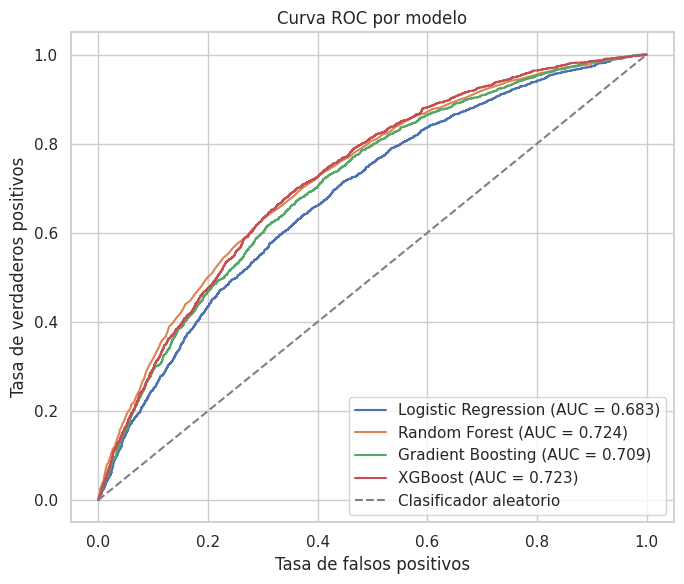

In [50]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 6))
for nombre, pipe in pipelines.items():
    probas = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probas)
    auc_modelo = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc_modelo:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Clasificador aleatorio')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC por modelo')
plt.legend()
plt.tight_layout()
plt.show()


Se aprecia que las cuatro curvas se despegan claramente de la diagonal de referencia, confirmando que los cuatro modelos capturan una señal real y no están adivinando al azar. También se aprecia que Random Forest y XGBoost quedan prácticamente superpuestos en casi todo el rango (AUC 0.724 y 0.723, respectivamente). Se aprecia además que Gradient Boosting queda sistemáticamente por debajo de esos dos (AUC 0.709), y que Logistic Regression es, por un margen visible, la curva más cercana a la diagonal (AUC 0.683), es decir, la que menos distingue entre notas de buen y bajo desempeño.


### 8.4.1 Validación cruzada estratificada (robustez de la comparación)

Un solo `train_test_split` no dice qué tan estable es una métrica, pudo tocarnos una partición favorable o desfavorable por puro azar. Para confirmar si el "empate" en AUC entre Random Forest y XGBoost (y la ventaja de XGBoost en `recall`) es real o es ruido del split, repetimos la comparación con **5-fold cross-validation estratificado**: en vez de un solo train/test, se hacen 5 particiones distintas (conservando la proporción de clases en cada una), se entrena y evalúa 5 veces, y se reporta el promedio y la desviación estándar de cada métrica.

In [51]:
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

filas_kfold = []
for nombre, modelo in modelos.items():
    pipe = Pipeline([('preprocesador', preprocesador), ('modelo', modelo)])
    res = cross_validate(pipe, X, y, cv=skf, scoring=['roc_auc', 'recall', 'f1'], n_jobs=-1)
    filas_kfold.append({
        'modelo': nombre,
        'auc_media': res['test_roc_auc'].mean(), 'auc_std': res['test_roc_auc'].std(),
        'recall_media': res['test_recall'].mean(), 'recall_std': res['test_recall'].std(),
        'f1_media': res['test_f1'].mean(), 'f1_std': res['test_f1'].std(),
    })

kfold_df = pd.DataFrame(filas_kfold).sort_values('auc_media', ascending=False)
print(kfold_df.round(4).to_string(index=False))


             modelo  auc_media  auc_std  recall_media  recall_std  f1_media  f1_std
      Random Forest     0.7245   0.0067        0.4758      0.0063    0.5420  0.0055
            XGBoost     0.7173   0.0057        0.5113      0.0054    0.5544  0.0061
  Gradient Boosting     0.7086   0.0052        0.3873      0.0052    0.4796  0.0062
Logistic Regression     0.6792   0.0056        0.3742      0.0062    0.4602  0.0059


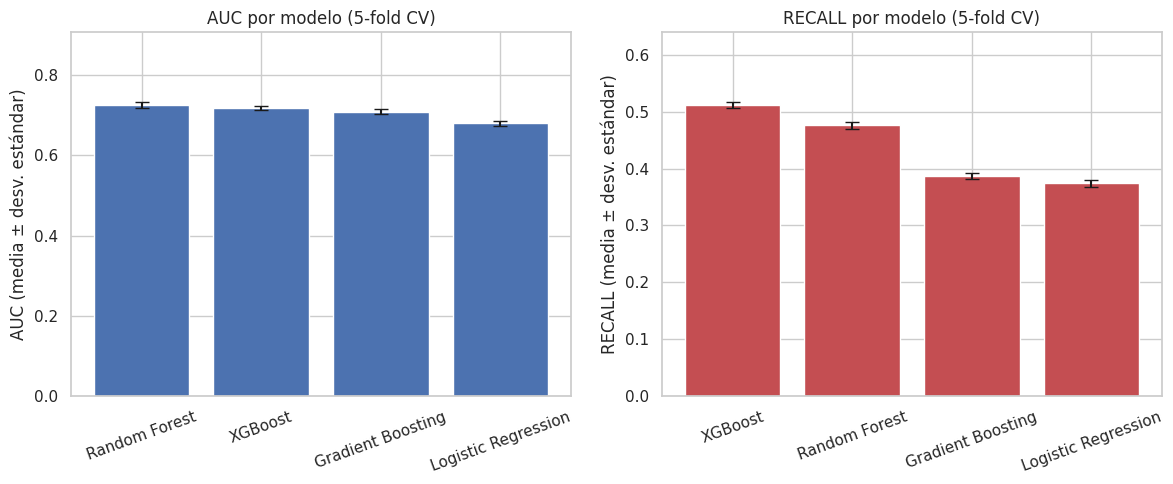

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metrica, color in zip(axes, ['auc', 'recall'], ['#4C72B0', '#C44E52']):
    orden = kfold_df.sort_values(f'{metrica}_media', ascending=False)
    ax.bar(orden['modelo'], orden[f'{metrica}_media'], yerr=orden[f'{metrica}_std'],
           capsize=5, color=color)
    ax.set_title(f'{metrica.upper()} por modelo (5-fold CV)')
    ax.set_ylabel(f'{metrica.upper()} (media ± desv. estándar)')
    ax.set_ylim(0, orden[f'{metrica}_media'].max() * 1.25)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


Panel izquierdo (AUC): mide qué tan bien distingue el modelo entre una nota de buen y de bajo desempeño, sin importar el punto de corte. Random Forest queda primero (0.7245), XGBoost muy cerca (0.7173), y aquí está el punto clave: sus barras de error casi se tocan. Eso significa que la diferencia entre ambos (0.007) es más chica que el ruido normal entre particiones, así que en la práctica es un empate: no se puede decir con confianza que uno sea mejor que el otro solo por AUC.

Panel derecho (Recall): mide qué proporción de las notas que realmente van a tener bajo desempeño el modelo logra detectar. Aquí el orden se invierte, XGBoost queda primero (0.511) y Random Forest segundo (0.476), y a diferencia del panel de AUC, las barras de error no se traslapan. Eso es una diferencia real y consistente: en las 5 particiones, XGBoost detectó sistemáticamente más casos de riesgo real que Random Forest.

La conclusión que arma la gráfica: si solo miraras AUC, Random Forest parecería "el mejor" por un margen que ni siquiera es confiable. Pero como el objetivo de negocio es un sistema de alerta (donde es peor no avisar de una nota riesgosa que avisar de más), la métrica que importa es recall  y ahí XGBoost tiene una ventaja real, no producto del azar del split. 


**El resultado confirma lo que vimos con un solo split, ahora con más confianza:**

- Random Forest sigue con el AUC más alto (0.7245 $\pm$ 0.0067), pero la diferencia con XGBoost (0.7173 $\pm$ 0.0057) es de apenas 0.007 -- más chica que la variabilidad combinada de ambos, así que se sigue considerando un empate práctico.
- **La ventaja de XGBoost en `recall` sí es robusta, no es ruido del split**: 0.5113 $\pm$ 0.0054 contra 0.4758 $\pm$ 0.0063 de Random Forest, una diferencia de 3.6 puntos porcentuales, mucho mayor que la variabilidad de cualquiera de los dos (0.005-0.006). En las 5 particiones distintas, XGBoost detecta consistentemente más casos reales de riesgo.
- Esto refuerza, con evidencia más sólida que un solo split, la decisión que se toma en la sección 8.5.

### 8.5 Selección del modelo final

Con un solo split, **Random Forest** y **XGBoost** quedan prácticamente empatados en AUC (0.724 vs 0.723). Elegimos **XGBoost** porque tiene mejor `recall` (0.470 vs 0.498) y `f1` (0.539 vs 0.546): para un sistema de *alerta* de riesgo, es más costoso no avisar de una nota que sí va a tener bajo desempeño (falso negativo) que avisar de más y que el editor revise una nota que en realidad estaba bien (falso positivo). Con AUC prácticamente igual, priorizamos el modelo que detecta más casos reales de riesgo.

**Esta decisión no depende de un solo split favorable**: la validación cruzada de la sección 8.4.1 confirma que la ventaja de XGBoost en `recall` (3.6 puntos porcentuales) es mucho mayor que la variabilidad entre particiones (±0.5-0.6 puntos), mientras que la diferencia de AUC con Random Forest (0.007) sigue estando dentro de esa variabilidad  es decir, el "empate en AUC, ventaja real en recall" no es un accidente del split, se sostiene con evidencia más robusta.


**Una ventaja adicional que no está en la tabla de métricas** : XGBoost es compatible con `TreeExplainer` de SHAP, que calcula explicaciones **rápidas y exactas** para modelos de árboles, esto es lo que después alimenta las tarjetas de "Factores que influyen en el desempeño" del dashboard. 

### 8.6 Ajuste del umbral de decisión

El umbral de 0.5 usado por defecto para convertir la probabilidad en una decisión binaria no está optimizado para el objetivo de negocio: en un sistema de *alerta* de riesgo, es más costoso no avisar de una nota que sí va a tener bajo desempeño (falso negativo) que avisar de más y que el editor revise una nota que en realidad estaba bien (falso positivo). Evaluamos el efecto de mover ese umbral sobre las probabilidades que ya calculó `pipeline_final` en el conjunto de prueba.


In [53]:
MODELO_FINAL = 'XGBoost'
pipeline_final = pipelines[MODELO_FINAL]

UMBRALES_A_PROBAR = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
probas_test = pipeline_final.predict_proba(X_test)[:, 1]

filas_umbral = []
for u in UMBRALES_A_PROBAR:
    pred_u = (probas_test >= u).astype(int)
    filas_umbral.append({
        'umbral': u,
        'recall': recall_score(y_test, pred_u),
        'precision': precision_score(y_test, pred_u),
        'f1': f1_score(y_test, pred_u),
    })

umbral_df = pd.DataFrame(filas_umbral)
print(umbral_df.round(3).to_string(index=False))


 umbral  recall  precision    f1
   0.30   0.820      0.517 0.634
   0.35   0.750      0.539 0.627
   0.40   0.682      0.565 0.618
   0.45   0.595      0.589 0.592
   0.50   0.498      0.603 0.546
   0.55   0.410      0.628 0.496
   0.60   0.319      0.656 0.429


Bajar el umbral a **0.40**, que coincide, no por casualidad, con el mismo percentil usado para definir la variable objetivo, sube el `recall` de forma considerable, con un costo moderado en `precision`, y mejora el `f1` general frente al umbral por defecto. Es el punto donde la mejora en detección de riesgo real ya no se paga con una caída fuerte de `precision`: bajar más (0.30-0.35) gana poco `recall` adicional a cambio de bastantes más falsas alarmas.

**Este es el umbral que usa la app en producción** (`app.py`, variable `UMBRAL_DECISION`), no el 0.5 por defecto de scikit-learn/XGBoost. La evaluación final de abajo usa este mismo umbral, para ser consistente con lo que ve el editor en el dashboard.


                precision    recall  f1-score   support

Buen desempeño       0.76      0.65      0.70      4187
Bajo desempeño       0.56      0.68      0.62      2759

      accuracy                           0.66      6946
     macro avg       0.66      0.67      0.66      6946
  weighted avg       0.68      0.66      0.67      6946



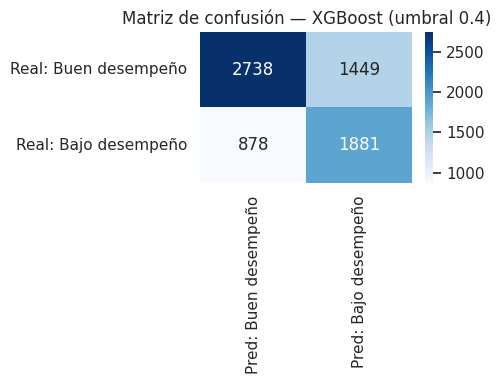

In [54]:
from sklearn.metrics import confusion_matrix, classification_report

MODELO_FINAL = 'XGBoost'
pipeline_final = pipelines[MODELO_FINAL]

# Umbral adoptado en la sección 8.6 (mismo que usa app.py), no el 0.5 por defecto de
# predict().
UMBRAL_DECISION = 0.40
y_pred_final = (pipeline_final.predict_proba(X_test)[:, 1] >= UMBRAL_DECISION).astype(int)

print(classification_report(y_test, y_pred_final, target_names=['Buen desempeño', 'Bajo desempeño']))

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred: Buen desempeño', 'Pred: Bajo desempeño'],
    yticklabels=['Real: Buen desempeño', 'Real: Bajo desempeño'],
)
plt.title(f'Matriz de confusión — {MODELO_FINAL} (umbral {UMBRAL_DECISION})')
plt.tight_layout()
plt.show()


Filas = lo que realmente pasó, columnas = lo que predijo el modelo. 

La diagonal (arriba-izquierda y abajo-derecha) son los aciertos; las otras dos celdas son los errores 

Abajo-izquierda son notas de bajo desempeño que el modelo no detectó (falsos negativos), el error que más nos importa minimizar en un sistema de alerta.

Aqui vemos (con el umbral de decisión de 0.40 adoptado en la sección 8.6):
- **Buen desempeño** (4,187 notas reales en test): precision 0.76, recall 0.65, el modelo identifica correctamente al 65% de las notas que sí tuvieron buen desempeño .
- **Bajo desempeño** (2,759 notas reales en test): precision 0.56, recall 0.68, de las notas que *realmente* tuvieron bajo desempeño.

**En la matriz de confusión:** las filas son la realidad, las columnas lo que predijo el modelo. La diagonal (arriba-izquierda y abajo-derecha) son los aciertos; las otras dos celdas son los errores.

- **2,738 aciertos** en "Buen desempeño" y **1,881 aciertos** en "Bajo desempeño".
- **1,449 falsos positivos**: notas que iban bien pero el modelo marcó como riesgo (falsa alarma, costo bajo, el editor revisa de más).
- **878 falsos negativos**: notas que sí tuvieron bajo desempeño pero el modelo dijo "está bien", **el error que más importa** en un sistema de alerta. Baja de 1,385 (con el umbral 0.5) a 878, más de un tercio menos.

**Análisis:**
- Con el umbral en 0.40, el modelo deja de ser "mucho mejor detectando notas buenas que riesgosas": el recall de ambas clases queda más parejo (0.65 vs 0.68) y un accuracy total un poco menor (0.665 vs 0.673).
- **De cada 3 notas que realmente van a tener bajo desempeño, el modelo avisa de 2** (1,881 de 2,759) -- no es perfecto pero funciona bien.
- La **precisión de 0.56 en "Bajo desempeño"** cuando el modelo marca una nota como riesgo,  acierta un poco menos seguido (56%) -- el costo esperado de priorizar detectar más riesgo real.



## 9. Explicabilidad con SHAP

El modelo XGBoost predice bien, pero es una "caja negra" para el Director Editorial. SHAP nos dice, para cada predicción, **cuánto empujó cada variable** el resultado hacia "riesgo alto" o "riesgo bajo", esto es lo que va a alimentar los "Factores de riesgo" del dashboard.

Usamos `TreeExplainer` sobre los datos ya transformados por el preprocesador.

shap_values shape: (6946, 63)


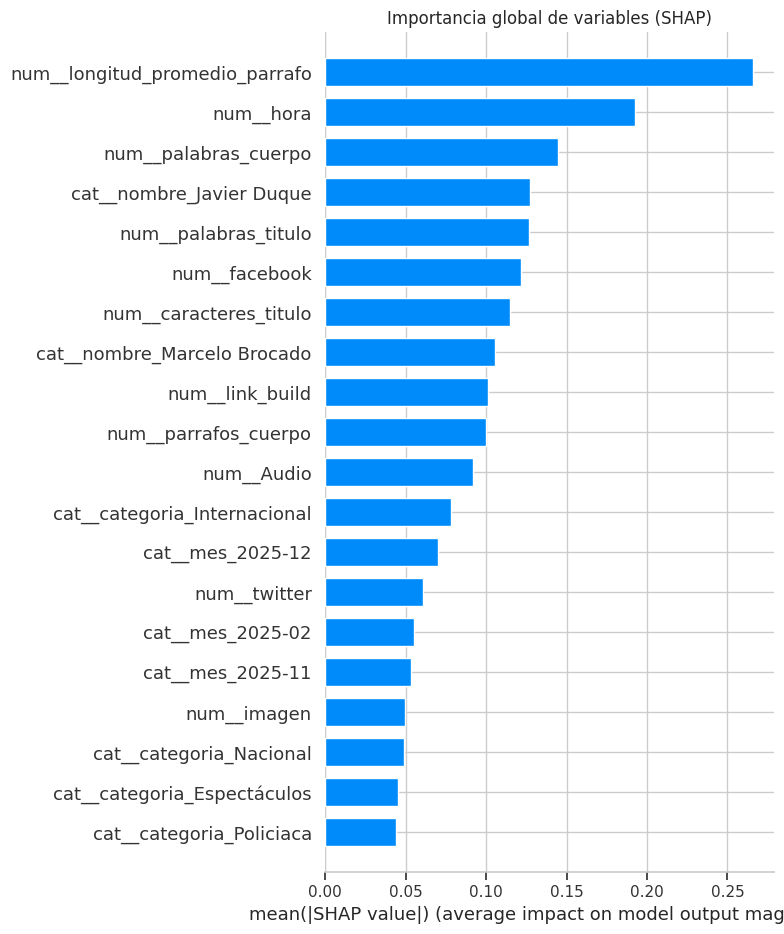

In [55]:
import shap
import xgboost as xgb

modelo_xgb = pipeline_final.named_steps['modelo']
preprocesador_fit = pipeline_final.named_steps['preprocesador']

X_test_transformado = preprocesador_fit.transform(X_test)
if hasattr(X_test_transformado, 'toarray'):
    X_test_transformado = X_test_transformado.toarray()
nombres_features = preprocesador_fit.get_feature_names_out()

# Nota técnica: shap.TreeExplainer falla con esta combinación de versiones de
# xgboost/shap, se evita usando  el cálculo nativo de SHAP que trae XGBoost (pred_contribs=True) , es el mismo
# algoritmo, solo que XGBoost lo calcula directamente sin pasar por el parser de shap.
booster = modelo_xgb.get_booster()
dmatrix = xgb.DMatrix(X_test_transformado, feature_names=list(nombres_features))
contribuciones = booster.predict(dmatrix, pred_contribs=True)
shap_values = contribuciones[:, :-1]  # la última columna es el valor base (bias), no una feature

print(f'shap_values shape: {shap_values.shape}')

shap.summary_plot(shap_values, X_test_transformado, feature_names=nombres_features, plot_type='bar', show=False)
plt.title('Importancia global de variables (SHAP)')
plt.tight_layout()
plt.show()

Se observa en la gráfica que se ordena las variables de mayor a menor importancia promedio (barra más larga = más peso en las predicciones del modelo). Solo dice *qué tanto* influye cada variable, no *hacia dónde* empuja el riesgo.

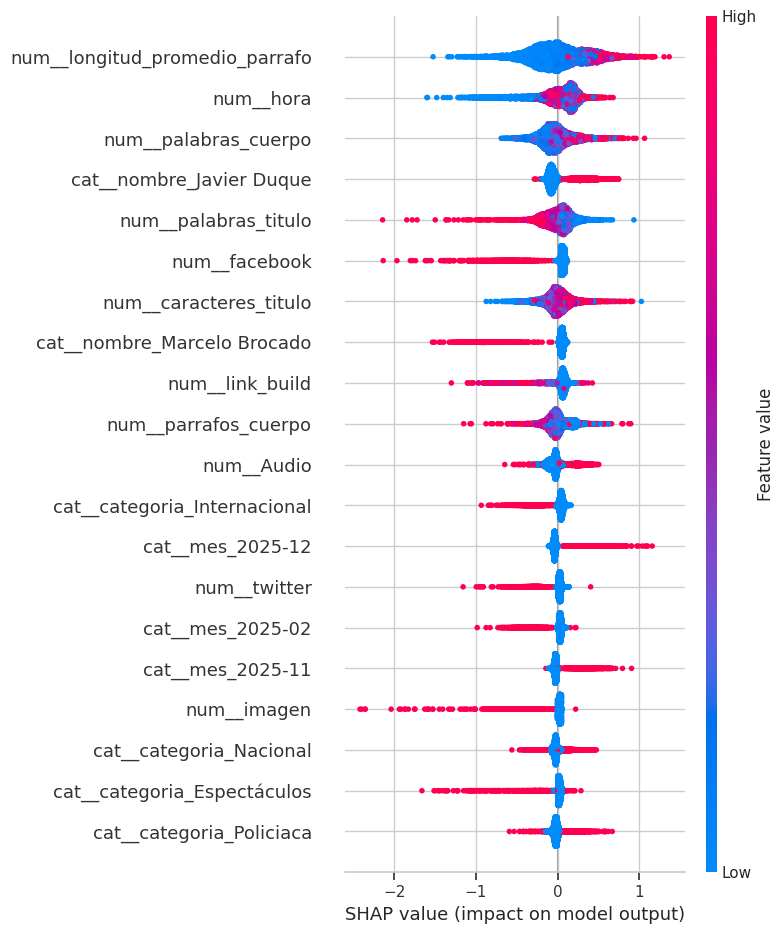

In [56]:
# El "bar" de arriba solo dice qué tan importante es cada variable en promedio.
# Este gráfico (beeswarm) además muestra la DIRECCIÓN: rojo = valor alto de la variable,
# azul = valor bajo; a la derecha del cero empuja hacia "bajo desempeño", a la izquierda hacia "buen desempeño".
shap.summary_plot(shap_values, X_test_transformado, feature_names=nombres_features, show=False)
plt.tight_layout()
plt.show()

**Gráfica (beeswarm):** esta gráfica resume el SHAP.

- **Eje Y**: las variables, ordenadas de más a menos importante en general (arriba = más importante).
- **Eje X**: el "SHAP value" , cuánto empujó esa variable la predicción para **una nota específica**. A la derecha del 0 = empuja hacia "bajo desempeño"; a la izquierda = empuja hacia "buen desempeño".
- **Cada punto es una nota** del conjunto de test, por eso se ve como una nube, no una barra.
- **El color es el valor real de esa variable en esa nota**: rojo = valor alto, azul = valor bajo (para variables categóricas tipo `cat__nombre_Javier Duque`, rojo = "sí es de ese autor", azul = "no es de ese autor").
- **Lo ancho del amontonamiento** en cada fila muestra cuántas notas caen en ese rango de SHAP , una "panza" ancha significa que muchas notas comparten un efecto similar.

**Ejemplo concreto, con la variable más importante (`num__longitud_promedio_parrafo`, arriba de todo):**

Los puntos **rojos** (párrafos largos) están mayormente del lado **derecho** (SHAP positivo → empuja a "bajo desempeño"), y los puntos **azules** (párrafos cortos) están del lado **izquierdo** (SHAP negativo → empuja a "buen desempeño"). Esto es justo lo que ya se confirmó con datos reales antes: párrafos más largos = peor desempeño. La gráfica beeswarm deja ver esa misma relación, pero nota por nota, no solo como un promedio.

Otro ejemplo, con una variable categórica (`cat__nombre_Javier Duque`): los puntos rojos (las notas que SÍ son de ese autor) tienden a estar de un lado específico del cero, mientras los azules (todas las demás notas, sin importar el autor) se agrupan cerca del cero -- normal, porque "no ser Javier Duque" no dice mucho por sí solo, mientras que "sí serlo" sí tiene un efecto medible.


### 9.1 Importancia agrupada por variable original

`categoria`, `nombre`, `dia_semana`, `mes`, `tipo_contenido` y `horario` quedaron repartidas en varias columnas por el one-hot encoding. Sumamos la importancia de todas las columnas de cada variable para poder comparar "manzanas con manzanas" contra las numéricas.

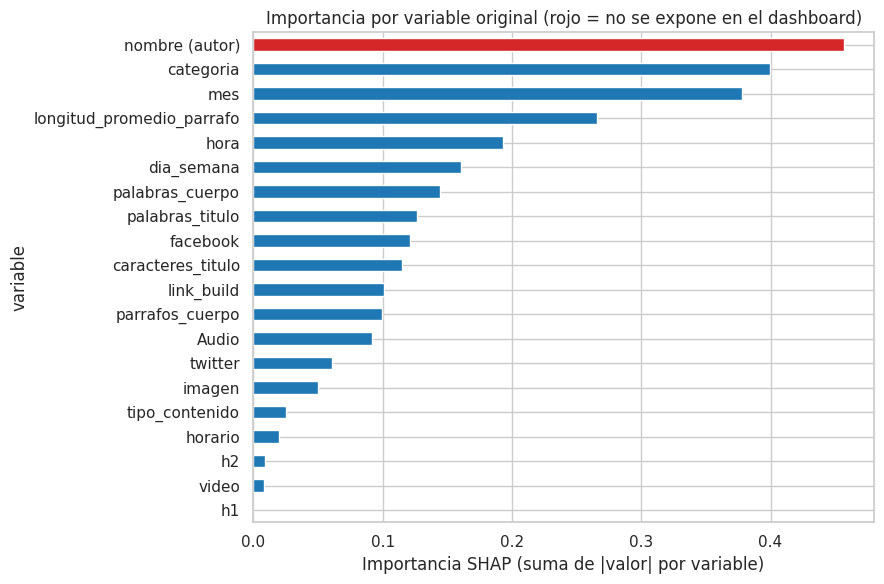

variable
nombre (autor)               0.457
categoria                    0.400
mes                          0.378
longitud_promedio_parrafo    0.266
hora                         0.193
dia_semana                   0.161
palabras_cuerpo              0.145
palabras_titulo              0.127
facebook                     0.121
caracteres_titulo            0.115
link_build                   0.101
parrafos_cuerpo              0.100
Audio                        0.092
twitter                      0.061
imagen                       0.050
tipo_contenido               0.025
horario                      0.020
h2                           0.009
video                        0.008
h1                           0.000
Name: importancia_media_abs, dtype: float32


In [57]:
importancia = pd.DataFrame({
    'feature': nombres_features,
    'importancia_media_abs': np.abs(shap_values).mean(axis=0),
})

def variable_original(f):
    for prefijo, etiqueta in [
        ('cat__categoria_', 'categoria'), ('cat__nombre_', 'nombre (autor)'),
        ('cat__dia_semana_', 'dia_semana'), ('cat__mes_', 'mes'),
        ('cat__tipo_contenido_', 'tipo_contenido'), ('cat__horario_', 'horario'),
    ]:
        if f.startswith(prefijo):
            return etiqueta
    return f.replace('num__', '')

importancia['variable'] = importancia['feature'].apply(variable_original)
importancia_agrupada = (
    importancia.groupby('variable')['importancia_media_abs']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))
colores = ['#d62728' if v in ('nombre (autor)',) else '#1f77b4' for v in importancia_agrupada.index]
importancia_agrupada.plot(kind='barh', color=colores)
plt.gca().invert_yaxis()
plt.xlabel('Importancia SHAP (suma de |valor| por variable)')
plt.title('Importancia por variable original (rojo = no se expone en el dashboard)')
plt.tight_layout()
plt.show()

print(importancia_agrupada.round(3))

En la gráfia se observa que cada barra es una variable original (ya agrupando sus categorías del one-hot encoding). 

Barra más larga = más peso total en las predicciones. 
La barra roja (`nombre (autor)`) es la más importante del modelo ,  no se mostrará en el dashboard como "factor de riesgo", ya que equivaldría a evaluar al periodista y no a la nota.

### 9.2 Dirección del efecto (variables numéricas/accionables)

Para saber si un valor alto de cada variable *sube* o *baja* el riesgo, calculamos la correlación entre el valor de la variable y su propio SHAP value. Positivo = valores altos empujan hacia "bajo desempeño"; negativo = valores altos empujan hacia "buen desempeño". Esta es la tabla que va a alimentar directamente las "Acciones recomendadas" del dashboard.

/home/aldox/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/aldox/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


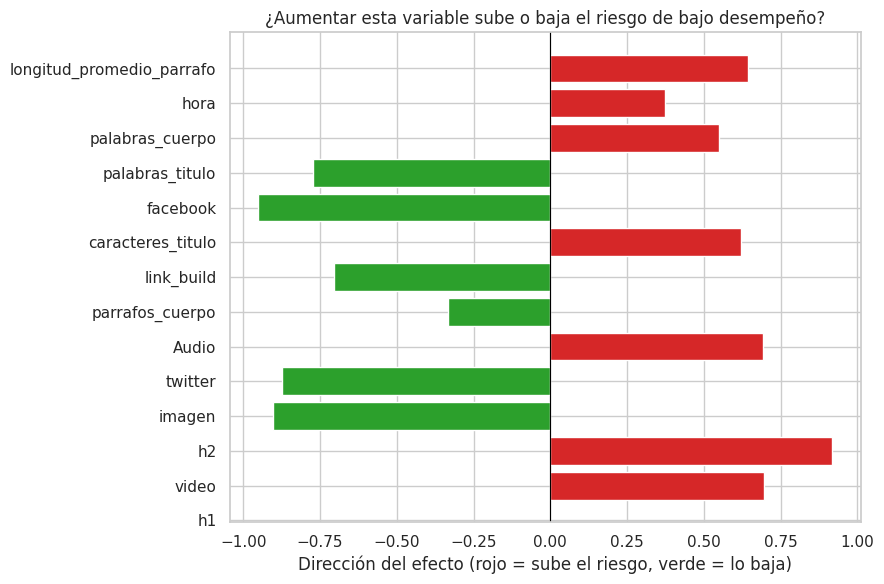

                 variable  importancia  direccion
longitud_promedio_parrafo        0.266      0.643
                     hora        0.193      0.374
          palabras_cuerpo        0.145      0.550
          palabras_titulo        0.127     -0.774
                 facebook        0.121     -0.951
        caracteres_titulo        0.115      0.620
               link_build        0.101     -0.704
          parrafos_cuerpo        0.100     -0.333
                    Audio        0.092      0.694
                  twitter        0.061     -0.873
                   imagen        0.050     -0.902
                       h2        0.009      0.917
                    video        0.008      0.697
                       h1        0.000        NaN


In [58]:
direccion = []
for feat in FEATURES_NUMERICAS:
    col = f'num__{feat}'
    idx = list(nombres_features).index(col)
    corr = np.corrcoef(X_test_transformado[:, idx], shap_values[:, idx])[0, 1]
    imp = np.abs(shap_values[:, idx]).mean()
    direccion.append({'variable': feat, 'importancia': imp, 'direccion': corr})

direccion_df = pd.DataFrame(direccion).sort_values('importancia', ascending=False)

plt.figure(figsize=(9, 6))
colores = ['#d62728' if d > 0 else '#2ca02c' for d in direccion_df['direccion']]
plt.barh(direccion_df['variable'], direccion_df['direccion'], color=colores)
plt.gca().invert_yaxis()
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Dirección del efecto (rojo = sube el riesgo, verde = lo baja)')
plt.title('¿Aumentar esta variable sube o baja el riesgo de bajo desempeño?')
plt.tight_layout()
plt.show()

print(direccion_df.round(3).to_string(index=False))

En la gráfica observamos que para cada variable, mide si sus valores *altos* están asociados a más riesgo o a menos riesgo  y qué tan fuerte/consistente es esa relación .

- **Barra roja hacia la derecha** = cuando esta variable tiene un valor alto, sube el riesgo de bajo desempeño.
- **Barra verde hacia la izquierda** , cuando esta variable tiene un valor alto, baja el riesgo (es protector).
- **El largo de la barra** = qué tan fuerte y consistente es ese efecto (no qué tan importante es la variable en general, eso se vio en la gráfica de barras/beeswarm anterior).

**Ejemplos concretos, con variables que ya conocemos de antes:**

- **`longitud_promedio_parrafo` (roja, la más larga de las rojas)**: párrafos largos = más riesgo. Coincide exactamente con lo que ya vimos en el EDA: entre más largo el párrafo promedio, menos vistas.
- **`palabras_cuerpo` (roja)**: cuerpos más largos = más riesgo. También coincide con la correlación -0.26 que vimos antes .
- **`facebook` e `imagen` (verdes, de las más largas)**: tener una incrustación de Facebook o traer imagen son las señales *protectoras* más fuertes de toda la tabla , bajan el riesgo de forma consistente.
- **`parrafos_cuerpo` (verde, pero corta)**: tener más párrafos (divididos) baja el riesgo un poco, pero es un efecto débil comparado con `longitud_promedio_parrafo` , tiene sentido, son casi la misma idea vista de dos formas, y ya vimos que la longitud promedio es la señal más fuerte de las dos.
- **`h1` (sin barra visible)**: prácticamente no tiene efecto .

Esta gráfica solo aplica a variables **numéricas** (por eso no aparecen categoría, autor, día, mes).


## 10. Función de inferencia
Hasta aquí todo el trabajo fue sobre datos históricos. Ahora construimos la pieza que usará el dashboard: una función que recibe una nota **nueva, antes de publicarse** (título, cuerpo, categoría, autor, multimedia, fecha/hora planeada) y devuelve el riesgo, el score y los factores que lo explican.

### 10.1 Calcular las features desde texto crudo

El editor puede pegar **HTML real** (el mismo formato que trae `nota` en el CMS) o escribir texto plano -- el formulario de Streamlit acepta ambos. Por eso `calcular_features_texto()` siempre quita etiquetas HTML para contar palabras (así nunca cuenta `<p>`, `<strong>`, etc. como si fueran texto real), y cuenta `parrafos_cuerpo` igual que en el entrenamiento: número de etiquetas `<p>` literales, sin ningún fallback de líneas en blanco. Si el editor escribe texto plano sin ninguna etiqueta `<p>`, el valor real es 0 -- exactamente lo que el modelo vio en entrenamiento para ese caso, así que no lo "corregimos" inventando párrafos, porque eso le daría al modelo una señal que nunca aprendió.

In [59]:
def calcular_features_texto(titulo: str, cuerpo: str) -> dict:
    caracteres_titulo = len(titulo)
    palabras_titulo = len(titulo.split())

    # El cuerpo puede venir en HTML (igual que en los datos de entrenamiento) o en texto
    # plano. Quitamos etiquetas y decodificamos entidades (&aacute; etc.) para contar
    # palabras reales, sin importar cuál de los dos formatos use el editor.
    texto_plano = re.sub(r'<[^>]+>', ' ', cuerpo)
    texto_plano = html_lib.unescape(texto_plano)
    palabras_cuerpo = len(texto_plano.split())

    # Párrafos: contamos '<p' literal, igual que en el entrenamiento (Fase 1) --
    # nota_df['parrafos_cuerpo'] = nota_df['nota'].str.count('<p'), sin fallback. Si el
    # texto viene plano (sin <p>), el valor real que vio el modelo es 0.
    parrafos_cuerpo = cuerpo.count('<p')

    longitud_promedio_parrafo = (
        palabras_cuerpo / parrafos_cuerpo if parrafos_cuerpo > 0 else palabras_cuerpo
    )

    return {
        'caracteres_titulo': caracteres_titulo,
        'palabras_titulo': palabras_titulo,
        'palabras_cuerpo': palabras_cuerpo,
        'parrafos_cuerpo': parrafos_cuerpo,
        'longitud_promedio_parrafo': longitud_promedio_parrafo,
    }


### 10.2 Traducir SHAP a "Factores de riesgo" en lenguaje humano

Usamos las direcciones que ya calculamos en la sección 9.2 para escribir, para cada variable numérica, una frase de cuando *perjudica* y una de cuando *ayuda*. `nombre` (autor) queda excluido de esta función por completo, nunca se muestra como factor.

In [60]:
FACTOR_TEMPLATES = {
    'longitud_promedio_parrafo': {
        'riesgo': 'Los párrafos son largos en promedio; divídelos en bloques más cortos.',
        'protector': 'La longitud de los párrafos es adecuada.',
    },
    'hora': {
        'riesgo': 'La hora de publicación elegida está asociada a menor desempeño para este tipo de nota; considera otro horario.',
        'protector': 'La hora de publicación elegida no está penalizando el desempeño de esta nota en particular.',
    },
    'palabras_cuerpo': {
        'riesgo': 'El cuerpo de la nota es más largo de lo recomendado, considera acortarlo.',
        'protector': 'La extensión del cuerpo es adecuada.',
    },
    'palabras_titulo': {
        'riesgo': 'El título tiene pocas palabras; prueba un título con más palabras.',
        'protector': 'El título tiene un buen número de palabras.',
    },
    'caracteres_titulo': {
        'riesgo': 'El título usa palabras largas; prueba sinónimos más cortos.',
        'protector': 'El título usa palabras de longitud adecuada.',
    },
    'link_build': {
        'riesgo': 'Falta link-building (enlaces internos/externos); agrega algunos.',
        'protector': 'El link-building es adecuado.',
    },
    'parrafos_cuerpo': {
        'riesgo': 'Muy pocos párrafos; divide el texto en más bloques.También puedes agregar nuevos párrafos con texto.',
        'protector': 'La cantidad de párrafos es adecuada.',
    },
    'facebook': {
        'riesgo': 'Falta código incrustado de post de Facebook; considera agregarla.',
        'protector': 'Tiene código incrustado de post de Facebook.',
    },
    'imagen': {
        'riesgo': 'Pocas o ninguna imagen; agrega al menos una.',
        'protector': 'Tiene suficientes imágenes.',
    },
    'twitter': {
        'riesgo': 'Falta código incrustado de post de X.',
        'protector': 'Tiene código incrustado de post de X.',
    },
    'video': {
        'riesgo': 'El video de youtube no está asociado a mejor desempeño en esta categoría (señal débil, revisar caso por caso).',
        'protector': 'El uso de video de youtube parece favorable aquí (señal débil).',
    },
    'Audio': {
        'riesgo': 'El audio no está asociado a mejor desempeño en los datos históricos (señal débil).',
        'protector': 'El uso de audio parece favorable aquí (señal débil).',
    },
}

def factores_de_riesgo(shap_fila, nombres_cols, top_n=5):
    """shap_fila: vector de SHAP para UNA sola nota. Devuelve top_n factores en texto plano."""
    pares = [
        (nombre, valor) for nombre, valor in zip(nombres_cols, shap_fila)
        if not nombre.startswith('cat__nombre_')  # nunca exponemos al autor
    ]
    pares.sort(key=lambda t: abs(t[1]), reverse=True)

    factores = []
    for nombre_col, shap_val in pares[:top_n]:
        if abs(shap_val) < 1e-6:
            continue
        es_riesgo = shap_val > 0

        if nombre_col.startswith('num__'):
            base = nombre_col.replace('num__', '')
            plantilla = FACTOR_TEMPLATES.get(base)
            if plantilla is None:
                continue
            texto = plantilla['riesgo'] if es_riesgo else plantilla['protector']
        elif nombre_col.startswith('cat__'):
            base, valor_categoria = nombre_col.replace('cat__', '').split('_', 1)
            direccion_txt = 'aumenta' if es_riesgo else 'reduce'
            texto = f'La variable "{base}" con valor "{valor_categoria}" {direccion_txt} el riesgo respecto al promedio.'
        else:
            continue

        factores.append({'variable': nombre_col, 'shap': float(shap_val), 'es_riesgo': es_riesgo, 'texto': texto})

    return factores

print('Función factores_de_riesgo lista.')

Función factores_de_riesgo lista.


### 10.3 Función principal: `analizar_nota()`



In [61]:
import datetime as dt 

def analizar_nota(
    titulo: str,
    cuerpo: str,
    categoria: str,
    nombre: str,
    fecha_publicacion: dt.datetime,
    imagen: int = 0,
    video: int = 0,
    twitter: int = 0,
    facebook: int = 0,
    audio: int = 0,
    h1: int = 0,
    h2: int = 0,
    link_build: int = 0,
) -> dict:
    feats_texto = calcular_features_texto(titulo, cuerpo)

    hora = fecha_publicacion.hour
    dia_semana = fecha_publicacion.strftime('%A')  # nombre en inglés, igual que en el entrenamiento
    mes = fecha_publicacion.strftime('%Y-%m')
    tiene_multimedia = (imagen > 0) or (video > 0) or (audio == 1)
    tipo_contenido = 'Multimedia' if tiene_multimedia else 'Texto'
    horario = clasificar_horario(hora)

    fila = pd.DataFrame([{
        **feats_texto,
        'h1': h1, 'h2': h2, 'link_build': link_build,
        'imagen': imagen, 'video': video, 'twitter': twitter, 'facebook': facebook,
        'hora': hora, 'Audio': audio,
        'categoria': categoria, 'nombre': nombre, 'dia_semana': dia_semana,
        'mes': mes, 'tipo_contenido': tipo_contenido, 'horario': horario,
    }])[FEATURES]

    probabilidad_riesgo = float(pipeline_final.predict_proba(fila)[0, 1])
    es_bajo_desempeno = probabilidad_riesgo >= 0.5

    fila_transformada = preprocesador_fit.transform(fila)
    if hasattr(fila_transformada, 'toarray'):
        fila_transformada = fila_transformada.toarray()
    dmatrix_fila = xgb.DMatrix(fila_transformada, feature_names=list(nombres_features))
    shap_fila = booster.predict(dmatrix_fila, pred_contribs=True)[0, :-1]

    factores = factores_de_riesgo(shap_fila, nombres_features, top_n=5)

    score_editorial = round((1 - probabilidad_riesgo) * 100)
    if probabilidad_riesgo < 0.35:
        decision_editorial = 'Publicar sin cambios'
    elif probabilidad_riesgo < 0.60:
        decision_editorial = 'Publicar con mejoras sugeridas'
    else:
        decision_editorial = 'Revisar antes de publicar'

    return {
        'riesgo_bajo_desempeno': es_bajo_desempeno,
        'probabilidad_riesgo': round(probabilidad_riesgo, 3),
        'score_editorial': score_editorial,
        'decision_editorial': decision_editorial,
        'factores_riesgo': factores,
        'features_calculadas': feats_texto | {'hora': hora, 'dia_semana': dia_semana, 'mes': mes, 'tipo_contenido': tipo_contenido, 'horario': horario},
    }

print('Función analizar_nota lista.')

Función analizar_nota lista.


Es la función principal que junta todo lo anterior, recibe una nota nueva y devuelve el reporte completo que usará el dashboard. En resumen:


- Calcula las features del título/cuerpo (calcular_features_texto) y de la fecha (hora, dia_semana, mes, horario) y multimedia (tipo_contenido).

- Arma una fila (fila) con esas features en el mismo orden/formato que usó el modelo al entrenar (FEATURES).
- Predice la probabilidad de bajo desempeño con el pipeline entrenado (probabilidad_riesgo), y la convierte en Sí/No con el umbral 0.5 (es_bajo_desempeno) .

- Calcula SHAP para esa nota específica (transforma la fila, arma el DMatrix, saca las contribuciones) y las traduce a factores_riesgo (los textos que irán el dashboard).

- Arma dos salidas para humanos: score_editorial (0-100, más alto = mejor, es solo el inverso de la probabilidad) y decision_editorial (3 niveles de texto según qué tan alta sea la probabilidad de riesgo: <0.35 publicar, 0.35-0.60 publicar con mejoras, >0.60 revisar).

- Devuelve todo junto en un diccionario: la decisión, el score, los factores, y las features calculadas (por si se quieren mostrar o depurar).

Es literalmente el "cerebro" que después se copia (con ajustes) a app.py para que el dashboard funcione sin tener que reentrenar nada.

### 10.4 Prueba con una nota de ejemplo

In [62]:
cuerpo_ejemplo = (
    'El Ayuntamiento de Veracruz anunció este martes el inicio de un nuevo programa de '
    'bacheo en las principales avenidas del puerto, con una inversión de 15 millones de pesos '
    'que se ejecutará durante los próximos tres meses en las zonas de mayor tránsito vehicular, '
    'según informó la Dirección de Obras Públicas durante una conferencia de prensa realizada '
    'esta mañana en las instalaciones del palacio municipal, donde también se detallaron los '
    'criterios técnicos utilizados para priorizar las calles que serán intervenidas primero.\n\n'
    'El director de Obras Públicas explicó que el programa contempla la reparación de más de '
    'doscientos puntos críticos identificados mediante un diagnóstico vial realizado en los '
    'últimos meses, y que se dará seguimiento puntual al avance de los trabajos a través de '
    'reportes semanales publicados en el portal de transparencia del municipio.'
)

resultado = analizar_nota(
    titulo='Ayuntamiento de Veracruz anuncia programa de bacheo con inversión de 15 millones de pesos',
    cuerpo=cuerpo_ejemplo,
    categoria='Veracruz',
    nombre='Javier Duque',
    fecha_publicacion=dt.datetime(2026, 8, 3, 20, 0),  # lunes 8pm, horario "Noche"
    imagen=0, video=0, twitter=0, facebook=0, audio=0, h1=0, h2=0, link_build=0,
)

print('Riesgo de bajo desempeño:', resultado['riesgo_bajo_desempeno'])
print('Probabilidad:', resultado['probabilidad_riesgo'])
print('Score editorial:', resultado['score_editorial'])
print('Decisión editorial:', resultado['decision_editorial'])
print()
print('Factores de riesgo:')
for f in resultado['factores_riesgo']:
    print(f" - [{'RIESGO' if f['es_riesgo'] else 'POSITIVO'}] {f['texto']}")

Riesgo de bajo desempeño: False
Probabilidad: 0.385
Score editorial: 61
Decisión editorial: Publicar con mejoras sugeridas

Factores de riesgo:
 - [POSITIVO] La extensión del cuerpo es adecuada.
 - [RIESGO] Los párrafos son largos en promedio; divídelos en bloques más cortos.
 - [POSITIVO] La variable "categoria" con valor "Veracruz" reduce el riesgo respecto al promedio.
 - [POSITIVO] El título tiene un buen número de palabras.
 - [POSITIVO] La variable "dia" con valor "semana_Monday" reduce el riesgo respecto al promedio.


### 10.5 Segundo ejemplo (nota de mayor riesgo)

Probamos ahora con una nota con características contrarias a la anterior: categoría de bajo desempeño típico, un solo párrafo muy largo, sin multimedia ni promoción, publicada tarde en la noche, para ver el otro extremo del sistema.

In [63]:
cuerpo_ejemplo_2 = (
    'La Asamblea General de las Naciones Unidas inicio este domingo una sesion extraordinaria '
    'para discutir el avance de los compromisos climaticos asumidos por los paises miembro durante '
    'la ultima cumbre internacional, en un contexto marcado por las divisiones entre las naciones '
    'desarrolladas y las economias emergentes respecto al financiamiento de las metas de reduccion '
    'de emisiones para la proxima decada, de acuerdo con el documento preliminar difundido horas '
    'antes por la secretaria del organismo, el cual establece un plazo de dieciocho meses para que '
    'cada delegacion presente su plan actualizado de transicion energetica, ademas de un mecanismo '
    'de revision independiente que evaluara el cumplimiento real de los compromisos frente a los '
    'anuncios hechos publicamente por cada gobierno durante las negociaciones previas, un punto que '
    'genero criticas inmediatas de varias delegaciones que consideran insuficiente el plazo propuesto.'
)

resultado_2 = analizar_nota(
    titulo='Asamblea General de la ONU discute nueva resolucion sobre cambio climatico en sesion extraordinaria',
    cuerpo=cuerpo_ejemplo_2,
    categoria='Internacional',
    nombre='Alexandra Bagel',
    fecha_publicacion=dt.datetime(2026, 8, 9, 23, 0),  # domingo 11pm, horario "Noche"
    imagen=0, video=0, twitter=0, facebook=0, audio=0, h1=0, h2=0, link_build=0,
)

print('Riesgo de bajo desempeño:', resultado_2['riesgo_bajo_desempeno'])
print('Probabilidad:', resultado_2['probabilidad_riesgo'])
print('Score editorial:', resultado_2['score_editorial'])
print('Decisión editorial:', resultado_2['decision_editorial'])
print()
print('Factores de riesgo:')
for f in resultado_2['factores_riesgo']:
    print(f" - [{'RIESGO' if f['es_riesgo'] else 'POSITIVO'}] {f['texto']}")


Riesgo de bajo desempeño: False
Probabilidad: 0.454
Score editorial: 55
Decisión editorial: Publicar con mejoras sugeridas

Factores de riesgo:
 - [RIESGO] Los párrafos son largos en promedio; divídelos en bloques más cortos.
 - [POSITIVO] La variable "categoria" con valor "Internacional" reduce el riesgo respecto al promedio.
 - [RIESGO] El título usa palabras largas; prueba sinónimos más cortos.
 - [RIESGO] Muy pocos párrafos; divide el texto en más bloques.También puedes agregar nuevos párrafos con texto.
 - [POSITIVO] La hora de publicación elegida no está penalizando el desempeño de esta nota en particular.


### 10.6 Tercer ejemplo (HTML real, con multimedia)

Los dos ejemplos anteriores usaron texto plano (separado por `\n\n`). Probamos ahora con **HTML real** (varias etiquetas `<p>`, como llegaría si el editor pega contenido desde un editor WYSIWYG), el otro formato de entrada que soporta `calcular_features_texto()`. Categoría Policiaca, con imagen y una incrustación de Twitter, publicada un miércoles en la mañana (uno de los mejores horarios según el EDA).

In [64]:
cuerpo_ejemplo_3 = (
    '<p>Elementos de la Policía Estatal detuvieron la madrugada de este miércoles a dos '
    'personas señaladas de robo a comercio en el centro de Veracruz, luego de una '
    'persecución que inició tras un reporte ciudadano al número de emergencias.</p>'
    '<p>De acuerdo con el reporte oficial, los detenidos intentaron huir a bordo de un '
    'vehículo con reporte de robo, pero fueron interceptados a unas cuadras del lugar de '
    'los hechos por una unidad que realizaba rondines de vigilancia en la zona.</p>'
    '<p>Ambos quedaron a disposición del Ministerio Público, que en las próximas horas '
    'determinará su situación jurídica. Las autoridades pidieron a la ciudadanía denunciar '
    'este tipo de hechos de inmediato para facilitar la reacción de los cuerpos de '
    'seguridad.</p>'
    '<blockquote class="twitter-tweet"><p>Reforzamos la vigilancia en el centro de la '
    'ciudad tras reportes de robo a comercio. #Veracruz #SeguridadCiudadana</p></blockquote>'
)

resultado_3 = analizar_nota(
    titulo='Detienen a dos personas por robo a comercio en el centro de Veracruz',
    cuerpo=cuerpo_ejemplo_3,
    categoria='Policiaca',
    nombre='José de Alba',
    fecha_publicacion=dt.datetime(2026, 8, 5, 8, 0),  # miércoles 8am, horario 'Mañana'
    imagen=1, video=0, twitter=1, facebook=0, audio=0, h1=0, h2=0, link_build=0,
)

print('Riesgo de bajo desempeño:', resultado_3['riesgo_bajo_desempeno'])
print('Probabilidad:', resultado_3['probabilidad_riesgo'])
print('Score editorial:', resultado_3['score_editorial'])
print('Decisión editorial:', resultado_3['decision_editorial'])
print()
print('Factores de riesgo:')
for f in resultado_3['factores_riesgo']:
    print(f" - [{'RIESGO' if f['es_riesgo'] else 'POSITIVO'}] {f['texto']}")


Riesgo de bajo desempeño: False
Probabilidad: 0.155
Score editorial: 85
Decisión editorial: Publicar sin cambios

Factores de riesgo:
 - [POSITIVO] Tiene código incrustado de post de X.
 - [POSITIVO] Tiene suficientes imágenes.
 - [RIESGO] La variable "categoria" con valor "Policiaca" aumenta el riesgo respecto al promedio.
 - [POSITIVO] La hora de publicación elegida no está penalizando el desempeño de esta nota en particular.
 - [POSITIVO] El uso de audio parece favorable aquí (señal débil).


## 11. Capa de recomendaciones

Ahora tomamos los `factores_riesgo` que ya calcula `analizar_nota()` y los convertimos en algo que el editor pueda leer y aplicar directamente: acciones recomendadas + 3 sugerencias de título. Construimos dos caminos:

1. **Opción Respaldo** (sin internet, sin API key),siempre funciona.
2. **LLM (Groq)**, más elaborado y natural, pero depende de una API externa.

 El sistema intenta primero el LLM y, si falla por cualquier motivo (sin API key, sin internet, timeout), cae automáticamente al Plan Respaldo así la demo en vivo nunca se queda sin respuesta.

### 11.1 Plan Respaldo: recomendaciones basadas en reglas

Convierte los factores de riesgo (los que ya empujan hacia "bajo desempeño") en una lista de acciones, y genera 3 variantes simples del título, no es tan elaborado como un LLM, pero no depende de nada externo.

In [65]:
def generar_recomendaciones_fallback(resultado: dict, titulo: str) -> dict:
    acciones = [f['texto'] for f in resultado['factores_riesgo'] if f['es_riesgo']]
    if not acciones:
        acciones = ['No se detectaron factores de riesgo relevantes; la nota luce bien tal como está.']

    sugerencias = [titulo]

    palabras = titulo.split()
    if len(titulo) > 60 and len(palabras) > 8:
        corto = ' '.join(palabras[:8])
        sugerencias.append(corto + '...')
    else:
        sugerencias.append(titulo.rstrip('.') + ': lo que debes saber')

    if not titulo.strip().endswith('?'):
        sugerencias.append('¿' + titulo[0].lower() + titulo[1:].rstrip('.') + '?')
    else:
        sugerencias.append(titulo.rstrip('?') + ' hoy')

    return {
        'fuente': 'reglas (fallback)',
        'acciones_recomendadas': acciones[:4],
        'sugerencias_titulos': sugerencias[:3],
    }

print('Función generar_recomendaciones_fallback lista.')

Función generar_recomendaciones_fallback lista.


### 11.2 Recomendaciones con LLM (Groq)

Le pedimos al modelo de lenguaje que redacte las recomendaciones y los títulos a partir de los mismos factores de riesgo, nunca le pedimos que prediga el riesgo, eso ya lo hizo XGBoost.

Usamos **Groq** (gratuito/muy rápido para este tipo de tareas). Requiere la variable de entorno `GROQ_API_KEY` (modelo `llama-3.3-70b-versatile`).

**La API key no se puso en el notebook** , se lee desde la variable de entorno en tiempo de ejecución. Si no está disponible, la función lanza una excepción que el wrapper de abajo captura para usar el plan Respaldo.

In [66]:
import os
import json as json_lib

def _cliente_llm():
    """Devuelve (cliente, modelo) usando Groq."""
    from openai import OpenAI

    if os.environ.get('GROQ_API_KEY'):
        cliente = OpenAI(
            api_key=os.environ['GROQ_API_KEY'],
            base_url='https://api.groq.com/openai/v1',
            timeout=10,
        )
        return cliente, 'llama-3.3-70b-versatile'

    raise RuntimeError('No hay GROQ_API_KEY configurada en el entorno.')


def generar_recomendaciones_llm(resultado: dict, titulo: str, cuerpo: str) -> dict:
    cliente, modelo = _cliente_llm()

    factores_texto = '\n'.join(f"- {f['texto']}" for f in resultado['factores_riesgo'])
    resumen_cuerpo = ' '.join(cuerpo.split()[:40])

    prompt = f'''Eres un asistente editorial de un medio de noticias. Con base en los siguientes
factores detectados por un modelo de riesgo (no los cuestiones, ya fueron calculados), redacta
recomendaciones breves y accionables para el editor, y 3 títulos alternativos para la misma nota.

Factores detectados:
{factores_texto}

Título actual: {titulo}
Inicio del cuerpo: {resumen_cuerpo}

Las acciones deben ser cosas que el editor puede cambiar en ESTA nota antes de publicar
(título, redacción, longitud, párrafos, imágenes, video, promoción en redes, enlaces).
NUNCA sugieras cambiar la categoría, el autor ni la fecha , esas son señales de contexto,
no decisiones editoriales prácticas.

Ordena "acciones_recomendadas" de mayor a menor impacto esperado, y "sugerencias_titulos"
de mayor a menor potencial de clics (la primera es la mejor).

Responde SOLO con un JSON con esta forma exacta:
{{"acciones_recomendadas": ["...", "...", "..."], "sugerencias_titulos": ["...", "...", "..."]}}'''

    respuesta = cliente.chat.completions.create(
        model=modelo,
        messages=[{'role': 'user', 'content': prompt}],
        response_format={'type': 'json_object'},
    )
    contenido = json_lib.loads(respuesta.choices[0].message.content)
    contenido['fuente'] = f'LLM ({modelo})'
    return contenido


def generar_recomendaciones(resultado: dict, titulo: str, cuerpo: str) -> dict:
    try:
        return generar_recomendaciones_llm(resultado, titulo, cuerpo)
    except Exception as e:
        print(f'[Aviso] LLM no disponible ({type(e).__name__}: {e}); usando plan Respaldo basado en reglas.')
        return generar_recomendaciones_fallback(resultado, titulo)

print('Funciones generar_recomendaciones_llm / generar_recomendaciones listas (Groq -> reglas).')


Funciones generar_recomendaciones_llm / generar_recomendaciones listas (Groq -> reglas).


### 11.3 Prueba (con la nota del primer ejemplo)

In [67]:
recomendaciones = generar_recomendaciones(resultado, titulo='Ayuntamiento de Veracruz anuncia programa de bacheo con inversión de 15 millones de pesos', cuerpo=cuerpo_ejemplo)

print('Fuente:', recomendaciones['fuente'])
print()
print('Acciones recomendadas:')
for a in recomendaciones['acciones_recomendadas']:
    print(' -', a)
print()
print('Sugerencias de título:')
for t in recomendaciones['sugerencias_titulos']:
    print(' -', t)

Fuente: LLM (llama-3.3-70b-versatile)

Acciones recomendadas:
 - Dividir los párrafos largos en bloques más cortos para mejorar la legibilidad
 - Añadir imágenes o videos que ilustren el programa de bacheo y su impacto en la comunidad
 - Realzar en la redacción la inversión de 15 millones de pesos y los beneficios del programa

Sugerencias de título:
 - Veracruz: 15 millones de pesos para bacheo en avenidas principales
 - Ayuntamiento de Veracruz invierte 15 millones en programa de bacheo
 - Bacheo en Veracruz: el Ayuntamiento compromete 15 millones de pesos


## 12. Guardar modelo entrenado

Guardamos `pipeline_final` (preprocesador + XGBoost) en un archivo con `joblib.

In [68]:
import joblib

MODEL_PATH = DATA_DIR.parent / 'modelo_riesgo.joblib'
joblib.dump(pipeline_final, MODEL_PATH)

print(f'Modelo guardado en: {MODEL_PATH}')
print(f'Tamaño del archivo: {MODEL_PATH.stat().st_size / 1024:.1f} KB')

Modelo guardado en: modelo_riesgo.joblib
Tamaño del archivo: 360.6 KB


In [69]:
# Verificación: cargamos el modelo desde el archivo (como lo hará la app de Streamlit)
# y confirmamos que da EXACTAMENTE la misma predicción que el original en memoria.
modelo_cargado = joblib.load(MODEL_PATH)

fila_prueba = X_test.iloc[[0]]

prob_original = pipeline_final.predict_proba(fila_prueba)[0, 1]
prob_cargado = modelo_cargado.predict_proba(fila_prueba)[0, 1]

print('Probabilidad con el modelo original:', round(prob_original, 6))
print('Probabilidad con el modelo cargado desde archivo:', round(prob_cargado, 6))
print('¿Son idénticas?', prob_original == prob_cargado)

Probabilidad con el modelo original: 0.228288
Probabilidad con el modelo cargado desde archivo: 0.228288
¿Son idénticas? True


## 13. Datos históricos reales para el dashboard (Proyección de visitas / Impacto de negocio)

El dashboard va a mostrar "Proyección de visitas" e "Impacto de negocio". En vez de inventar números, construimos aquí tablas de agregados **reales** por categoría (medianas de `ga_views`, `ga_engagement_rate`, `ga_bounce_rate`, `ga_revenue`, separadas por si la nota fue "bajo desempeño" o no) y la mejor hora histórica de publicación por categoría. Se guardan en un CSV pequeño que la app de Streamlit cargará directamente, sin necesitar el dataset completo.

In [70]:
tabla_historica = (
    df.groupby(['categoria', 'bajo_desempeno'])
    .agg(
        vistas_mediana=('ga_views', 'median'),
        vistas_p25=('ga_views', lambda s: s.quantile(0.25)),
        vistas_p75=('ga_views', lambda s: s.quantile(0.75)),
        engagement_mediana=('ga_engagement_rate', 'median'),
        bounce_mediana=('ga_bounce_rate', 'median'),
        revenue_mediana=('ga_revenue', 'median'),
        # Estas 5 alimentan la recomendacion de cantidad optima de palabras/caracteres en
        # la app -- mediana real por categoria, no un numero fijo inventado.
        palabras_mediana=('palabras_cuerpo', 'median'),
        parrafos_mediana=('parrafos_cuerpo', 'median'),
        longitud_parrafo_mediana=('longitud_promedio_parrafo', 'median'),
        caracteres_titulo_mediana=('caracteres_titulo', 'median'),
        palabras_titulo_mediana=('palabras_titulo', 'median'),
        n=('id', 'count'),
    )
    .reset_index()
)

HIST_PATH = DATA_DIR / 'historico_categoria.csv'
tabla_historica.to_csv(HIST_PATH, index=False)

print(f'Tabla guardada en: {HIST_PATH} ({len(tabla_historica)} filas)')
tabla_historica.head(6)


Tabla guardada en: datos/historico_categoria.csv (22 filas)


,categoria,bajo_desempeno,vistas_mediana,vistas_p25,vistas_p75,engagement_mediana,bounce_mediana,revenue_mediana,palabras_mediana,parrafos_mediana,longitud_parrafo_mediana,caracteres_titulo_mediana,palabras_titulo_mediana,n
0,Boca del Río,0,1971.0,1020.0,4046.00,0.623212,0.376788,23.978628,167.0,6.0,28.50,73.0,12.0,1381
1,Boca del Río,1,207.0,124.0,339.00,0.800419,0.199581,2.030345,178.0,5.0,31.00,74.0,12.0,920
2,Espectáculos,0,183.0,100.0,506.50,0.773766,0.226234,1.547278,227.0,6.0,33.50,72.0,12.0,1218
3,Espectáculos,1,36.0,26.0,47.00,0.750000,0.250000,0.248411,320.0,3.0,83.50,75.0,13.0,793
4,Estado,0,285.5,152.0,752.25,0.653413,0.346587,2.359228,177.0,5.0,30.25,76.0,12.0,2928
5,Estado,1,55.0,39.0,70.00,0.780000,0.220000,0.345861,225.0,5.0,40.00,78.0,12.0,1933


In [71]:
import json

# Mejor hora histórica por categoría (para "Tiempo óptimo de publicación").
# Exigimos un mínimo de notas por hora (MIN_N=30): con muy pocas notas, la mediana
# es puro ruido (ej. Veracruz a las 2am salía "la mejor hora" con solo 2 artículos).
MIN_N_HORA = 30

conteo_hora_categoria = df.groupby(['categoria', 'hora']).size().reset_index(name='n')
mediana_hora_categoria = df.groupby(['categoria', 'hora'])['ga_views'].median().reset_index()

hora_stats = conteo_hora_categoria.merge(mediana_hora_categoria, on=['categoria', 'hora'])
hora_stats_confiable = hora_stats[hora_stats['n'] >= MIN_N_HORA]

mejor_hora_categoria = (
    hora_stats_confiable
    .sort_values('ga_views', ascending=False)
    .drop_duplicates('categoria')
    .set_index('categoria')['hora']
    .to_dict()
)

MEJOR_HORA_PATH = DATA_DIR / 'mejor_hora_categoria.json'
with open(MEJOR_HORA_PATH, 'w') as f:
    json.dump({str(k): int(v) for k, v in mejor_hora_categoria.items()}, f, ensure_ascii=False, indent=1)

print(f'Guardado en: {MEJOR_HORA_PATH} (con mínimo {MIN_N_HORA} notas por hora)')
print(mejor_hora_categoria)

Guardado en: datos/mejor_hora_categoria.json (con mínimo 30 notas por hora)
{'Boca del Río': 7, 'Veracruz': 22, 'Policiaca': 6, 'Estado': 6, 'Nacional': 7, 'Sociedad': 17, 'Las Destacadas': 7, 'Espectáculos': 22, 'Internacional': 6, 'Tecnociencia': 21, 'Finanzas': 6}


## 14. Ensamblador final del reporte para el dashboard

Se junta `analizar_nota()` + `generar_recomendaciones()` + las tablas históricas de la sección 13 en un solo reporte, con exactamente los campos que necesita la interfaz. Cada campo nuevo (confianza, segmento, prioridad, hora óptima, proyección, impacto) está documentado con su fuente .

In [72]:
def nivel_riesgo_texto(prob):
    if prob < 0.35:
        return 'Bajo'
    elif prob < 0.60:
        return 'Medio'
    return 'Alto'


def estimar_impacto_y_proyeccion(categoria, prediccion_bajo_desempeno):
    """Real, basado en medianas históricas de la categoría (tabla_historica, sección 13)."""
    grupo = tabla_historica[
        (tabla_historica['categoria'] == categoria)
        & (tabla_historica['bajo_desempeno'] == int(prediccion_bajo_desempeno))
    ]
    grupo_bueno = tabla_historica[(tabla_historica['categoria'] == categoria) & (tabla_historica['bajo_desempeno'] == 0)]
    grupo_malo = tabla_historica[(tabla_historica['categoria'] == categoria) & (tabla_historica['bajo_desempeno'] == 1)]

    if grupo.empty:
        return None

    fila = grupo.iloc[0]
    impacto_potencial = None
    if not grupo_bueno.empty and not grupo_malo.empty:
        impacto_potencial = round(grupo_bueno.iloc[0]['vistas_mediana'] - grupo_malo.iloc[0]['vistas_mediana'])

    return {
        'vistas_estimadas': round(fila['vistas_mediana']),
        'vistas_rango': (round(fila['vistas_p25']), round(fila['vistas_p75'])),
        'engagement_rate_categoria': round(fila['engagement_mediana'], 3),
        'bounce_rate_categoria': round(fila['bounce_mediana'], 3),
        'revenue_mediana_categoria': round(fila['revenue_mediana'], 2),
        'impacto_potencial_visitas': impacto_potencial,
    }


print('Funciones de nivel de riesgo / proyección / impacto listas.')

Funciones de nivel de riesgo / proyección / impacto listas.


In [73]:
def construir_reporte_dashboard(resultado: dict, recomendaciones: dict, categoria: str, facebook: int, twitter: int) -> dict:
    prob = resultado['probabilidad_riesgo']

    # Confianza: qué tan lejos está la probabilidad de un empate 50/50 (real, no inventado)
    confianza_modelo = round(2 * abs(prob - 0.5), 2)

    # facebook/twitter son detecciones de incrustaciones (embeds) reales en el HTML de la nota, igual
    # que las cuenta analizar_html_contenido() en la app. Por eso es 'contenido social
    # embebido'.
    contenido_social_embebido = 'Sí' if (facebook > 0 or twitter > 0) else 'No'

    prioridad_por_decision = {
        'Publicar sin cambios': 'Baja',
        'Publicar con mejoras sugeridas': 'Media',
        'Revisar antes de publicar': 'Alta',
    }
    prioridad = prioridad_por_decision.get(resultado['decision_editorial'], 'Media')

    hora_optima = mejor_hora_categoria.get(categoria)

    proyeccion = estimar_impacto_y_proyeccion(categoria, resultado['riesgo_bajo_desempeno'])

    # Etiquetas de impacto por posición (el prompt del LLM ya ordena de mayor a menor impacto/potencial)
    etiquetas_titulos = ['Muy alto', 'Alto', 'Medio']
    etiquetas_acciones = ['Alto', 'Medio', 'Bajo']

    sugerencias_titulos = [
        {'titulo': t, 'potencial_clics': etiquetas_titulos[min(i, len(etiquetas_titulos) - 1)]}
        for i, t in enumerate(recomendaciones['sugerencias_titulos'])
    ]
    acciones_recomendadas = [
        {'texto': a, 'impacto': etiquetas_acciones[min(i, len(etiquetas_acciones) - 1)]}
        for i, a in enumerate(recomendaciones['acciones_recomendadas'])
    ]

    return {
        'probabilidad_riesgo': prob,
        'nivel_riesgo': nivel_riesgo_texto(prob),
        'score_editorial': resultado['score_editorial'],
        'confianza_modelo': confianza_modelo,
        'contenido_social_embebido': contenido_social_embebido,
        'decision_editorial': resultado['decision_editorial'],
        'prioridad': prioridad,
        'hora_optima_publicacion': hora_optima,
        'proyeccion_visitas': proyeccion,
        'factores_riesgo': resultado['factores_riesgo'],
        'sugerencias_titulos': sugerencias_titulos,
        'acciones_recomendadas': acciones_recomendadas,
        'fuente_recomendaciones': recomendaciones['fuente'],
    }

print('Función construir_reporte_dashboard lista.')

Función construir_reporte_dashboard lista.


### 14.1 Prueba del reporte completo

In [74]:
# Nota de prueba con TODAS las señales de multimedia/embeds activadas, para confirmar
# qué campos del reporte sí las reflejan y cuáles no.
resultado_multimedia = analizar_nota(
    titulo='Alcalde presenta reporte de obras con imágenes y video del recorrido',
    cuerpo=cuerpo_ejemplo_3,  # ya trae <p> reales y un <blockquote> de Twitter (sección 10.6)
    categoria='Veracruz',
    nombre='José de Alba',
    fecha_publicacion=dt.datetime(2026, 8, 5, 8, 0),
    imagen=1, video=1, twitter=1, facebook=1, audio=1, h1=0, h2=0, link_build=1,
)
recomendaciones_multimedia = generar_recomendaciones(
    resultado_multimedia,
    titulo='Alcalde presenta reporte de obras con imágenes y video del recorrido',
    cuerpo=cuerpo_ejemplo_3,
)
reporte = construir_reporte_dashboard(
    resultado_multimedia, recomendaciones_multimedia,
    categoria='Veracruz', facebook=1, twitter=1,
)

import pprint
pprint.pprint(reporte, width=100)

print()
print('--- Dónde queda cada señal ---')
print('twitter=1, facebook=1  ->  contenido_social_embebido:', reporte['contenido_social_embebido'])
print('video=1, audio=1, imagen=1  ->  NO tienen campo propio en `reporte`;')
print('  en la app real se muestran aparte, en el panel "Detectado automáticamente en el contenido".')
print('  Aquí solo influyen de forma indirecta, si SHAP los considera relevantes para ESTA nota:')
print('  (revisa si aparecen mencionados en factores_riesgo abajo)')
for f in resultado_multimedia['factores_riesgo']:
    print(f"   - [{'RIESGO' if f['es_riesgo'] else 'POSITIVO'}] {f['texto']}")


{'acciones_recomendadas': [{'impacto': 'Alto',
                            'texto': 'Retirar o revisar el código incrustado de posts de X y '
                                     'Facebook para evitar problemas de compatibilidad o '
                                     'seguridad'},
                           {'impacto': 'Medio',
                            'texto': 'Considerar la remoción del audio debido a su bajo desempeño '
                                     'en los datos históricos y la falta de asociación con un '
                                     'mejor desempeño'},
                           {'impacto': 'Bajo',
                            'texto': 'Optimizar la integración del video del recorrido para '
                                     'mejorar el engagement del lector'}],
 'confianza_modelo': 0.78,
 'contenido_social_embebido': 'Sí',
 'decision_editorial': 'Publicar sin cambios',
 'factores_riesgo': [{'es_riesgo': False,
                      'shap': -0.57938778400421

- **Generalización a otros medios**: si el sistema se pensara como producto para más de un medio, habría que generalizar las categorías/taxonomía y el pipeline de reentrenamiento, que hoy están cableados específicamente a este medio.

### 15.4 Reproducibilidad

El notebook detecta automáticamente si corre en Google Colab (`IN_COLAB`) e instala ahí las dos dependencias que no vienen preinstaladas (`shap`, `sentence-transformers`). 

Si no hay `GROQ_API_KEY` en el entorno cae automáticamente al Plan Respaldo basado en reglas, sin lanzar ningún error.

Para ejecutar el notebook en Google Colab:

- Sube la carpeta datos/ completa (con cms-2025.csv y google-analytics-2025.csv) a tu Google Drive, en la ruta: MyDrive/proyecto_final/datos/
- Abre notebook_analisis.ipynb en Colab y corre todas las celdas en orden (Entorno de ejecución → Ejecutar todas). Cuando pida montar Drive, autoriza el acceso.
shap y sentence-transformers se instalan solos (celda 1), no hace falta nada manual.
- La sección de recomendaciones con LLM es opcional: si no configuras GROQ_API_KEY como variable de entorno, el notebook usa automáticamente el plan de respaldo (reglas), sin error.
- Si la ruta de Drive es distinta a MyDrive/proyecto_final/datos/: edita DATA_DIR en la Sección 1 del notebook para que apunte a donde subiste los archivos.